#### Importar librerias

In [1]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import matplotlib.ticker as mtick
import matplotlib.dates as mdatesx
import matplotlib.transforms as transforms
from matplotlib.patches import Patch
import matplotlib.ticker as ticker
from scipy.interpolate import make_interp_spline
import calendar

#### Seleccionar Fecha

In [ ]:
# Elegir ANIO y MES que corresponda

ANIO = 2026
MES = 5

df = pd.DataFrame()
df["anio"] = ANIO
df["mes"] = MES

fecha_corte = pd.Timestamp(year=ANIO, month=MES, day=1) + pd.offsets.MonthEnd(0)

#### Drive - Colab

In [ ]:
######### Para usar con colab ###########
### Comentar si se usa fuera de colab ###

"""
import os
from google.colab import drive

drive.mount('/content/drive')
ruta_drive = r"/content/drive/MyDrive/_DPAEE/Automatización de Informes"
os.listdir(ruta_drive)

carpeta = f"{ANIO}-{MES}"
ruta_completa = os.path.join(ruta_drive, carpeta)

# Crear carpeta (no tira error si ya existe)
os.makedirs(ruta_completa, exist_ok=True)

#### Entorno local

In [ ]:
############## Para usar en entorno local #################
###### Comentar si se usa fuera de un entorno local #######

ruta_carpeta = r"C:\Users\janis\Desktop\DPAEE\Automatización de Informes\Fiscal"
ruta = f"{ruta_carpeta}\Gráficos Fiscal\PBA"

carpeta = f"{ANIO}-{MES}"

ruta_completa = os.path.join(ruta, carpeta)

print("Ruta final:")
print(ruta_completa)

print("Existe ruta madre:", os.path.exists(ruta))

# Crear carpeta
os.makedirs(ruta_completa, exist_ok=True)

print("Carpeta creada correctamente")



Ruta final:
C:\Users\janis\Desktop\DPAEE\Automatización de Informes\Fiscal\Gráficos Fiscal\PBA\2026-4
Existe ruta madre: True
Carpeta creada correctamente


<>:5: SyntaxWarning: "\G" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\G"? A raw string is also an option.
<>:5: SyntaxWarning: "\G" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\G"? A raw string is also an option.
C:\Users\janis\AppData\Local\Temp\ipykernel_14380\1521821049.py:5: SyntaxWarning: "\G" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\G"? A raw string is also an option.
  ruta = f"{ruta_carpeta}\Gráficos Fiscal\PBA"


### Definición de listas con las variables seleccionadas para cada gráfico

In [ ]:
# Definición de listas con las variables seleccionadas para cada gráfico

#################################
###########   P B A   ###########
#################################


# Gráfico Total - Últimos 12 meses variación interanual
lista_0 = [
                'Total RP corriente_defl',
                'Total RON corriente_defl',
                'Total_Total_defl'
]

# Gráfico líneas comparativo último mes y año anterior (Var a/a)
lista_1 = [
                'Trans. Bs+FOPROVI+Imp. Energía+Planes_defl',
                'IIBB_defl',
                'Inmobiliario_total_defl',
                'Sellos_defl',
                'Automotor_defl'
]

# Gráfico de barras último valor y el del año anterior:
lista_2 = [
                'Total RP corriente_defl',
                'IIBB_defl',
                'Inmobiliario_total_defl',
                'Automotor_defl',
                'Sellos_defl',
                'Trans. Bs+FOPROVI+Imp. Energía+Planes_defl'
]

# Gráfico de barras horizontales con eje centrado YoY:
lista_3 = [
                'Trans. Bs+FOPROVI+Imp. Energía+Planes_defl',
                'Sellos_defl',
                'Automotor_defl',
                'Inmobiliario_total_defl',
                'IIBB_defl' ,
                'Total RP corriente_defl'
]

# Gráfico de barras Acumulado - último valor y el del año anterior:
lista_4_0 = [
                'Total RP corriente_defl_acum',
                'IIBB_defl_acum',
                'Inmobiliario_total_defl_acum',
                'Automotor_defl_acum',
                'Sellos_defl_acum',
                'Trans. Bs+FOPROVI+Imp. Energía+Planes_defl_acum'
]

# Gráfico de barras Acumulado - último valor y el del año anterior  YoY:
lista_4 = [
                'Trans. Bs+FOPROVI+Imp. Energía+Planes_defl_acum',
                'Sellos_defl_acum',
                'Automotor_defl_acum',
                'Inmobiliario_total_defl_acum',
                'IIBB_defl_acum',
                'Total RP corriente_defl_acum'
]




# Gráfico de barras último valor y el del año anterior:
lista_5 = [
                'Total RON corriente_defl',
                'Copa + Ley_defl',
                'Resto + Tr_ss_defl'
]

# Gráfico de barras horizontales con eje centrado YoY:
lista_6 = [
                'Resto + Tr_ss_defl',
                'Copa + Ley_defl',
                'Total RON corriente_defl'
]

# Gráfico de barras acumulado último valor y valor del año anterior:
lista_7 = [
                'Total RON corriente_defl_acum',
                'Copa + Ley_defl_acum',
                'Resto + Tr_ss_defl_acum'
]

# Gráfico de barras horizontales con eje centrado Acumualado YoY:
lista_8 = [
                'Resto + Tr_ss_defl_acum',
                'Copa + Ley_defl_acum',
                'Total RON corriente_defl_acum'
]


####################################################
######## TRANSFERENCIAS NACION A MUNICIPIOS ########
####################################################


# Gráfico de barras apiladas último año y año anterior
lista_9 = [     'Resto_trans_defl',
                'Plan Nacional de Alfabetizacion_defl',
                'Funcionamiento de Hospitales_defl',
                'Gestion Educativa y Politicas Socioeducativas_defl',
               #'Regulacion de la Ablacion e Implantes_defl',
               #'Fortalecimiento de los Sistemas Provinciales de Salud_defl


]

# Lista que se obtiene en 'Fondos que más transferencias recibieron'
#lista_top_x_acum = []

# Gráfico de barras apiladas acumulado último año y año anterior
lista_10 = [
               'Relaciones con las Provincias y Desarrollo Regional_defl_acum',
               'Funcionamiento de Hospitales_defl_acum',
               'Gestion Educativa y Politicas Socioeducativas_defl_acum',
               'Regulacion de la Ablacion e Implantes_defl_acum',
               'Fortalecimiento de los Sistemas Provinciales de Salud_defl_acum',
               'Plan Nacional de Alfabetizacion_defl_acum',
               'Resto_trans_defl_acum'
]


### Definición de listas con las etiquetas para cada gráfico

In [ ]:
etiquetas_2 = [
            'Total',
            'IIBB',
            'Inmobiliario',
            'Automotor',
            'Sellos',
            'Resto'
]

etiquetas_3 = [
            'Resto',
            'Sellos',
            'Automotor',
            'Inmobiliario',
            'IIBB',
            'Total',
]

etiquetas_7 = [
            'Total',
            'Copart. + Ley de Fin. \nEducativo',
            'Resto de tributos'
]

etiquetas_9 = [
            'Resto Transferencias',
            'Plan Nacional de Alfabetizacion',
            'Funcionamiento de Hospital',
            'Gestion Educativa y Politicas \n Socioeducativas',
            #'Regulacion de la Ablacion e \n Implantes',
            #'Fortalecimiento de los Sistemas \n Provinciales de Salud',
            'Total'
]

etiquetas_10 = [
            'Resto Transferencias',
            'Relaciones con las Provincias y \n Desarrollo Regional',
            'Plan Nacional de Alfabetizacion',
            'Funcionamiento de Hospital',
            'Total'
            #'Gestion Educativa y Politicas \n Socioeducativas',
            #'Regulacion de la Ablacion e \n Implantes',
            #'Fortalecimiento de los Sistemas \n Provinciales de Salud',


]

### BBDD - Provincia de Buenos Aires

In [ ]:
fiscal_db = pd.read_excel("Fiscal_BBDD.xlsx", sheet_name='PBA')
fiscal_db.columns = fiscal_db.columns.str.strip()
pd.set_option('display.float_format', '{:.2f}'.format)
#fiscal_db.tail(2)

In [ ]:
# Crear Deflactor sobre el último dato de IPC

ultimo_valor = fiscal_db['IPC Dic16=100'].iloc[-1]


In [ ]:

# Cálculo de las variables Deflactadas + Incorporación a la base

fiscal_db['Resto + Tr_ss'] = fiscal_db['Resto de tributos (leyes y regimenes especiales)'] + fiscal_db['transferencia de servicios']

cols = fiscal_db.select_dtypes(include='number').columns

for col in cols:
    fiscal_db[f'{col}_defl'] = fiscal_db[col] * ultimo_valor / fiscal_db['IPC Dic16=100']

In [ ]:
# Agregar la columna 'TOTAL_TOTAL_defl'

fiscal_db["Total_Total_defl"] = fiscal_db["Total RP corriente_defl"] + fiscal_db["Total RON corriente_defl"]

In [ ]:
pd.set_option('display.max_columns', None)
#fiscal_db.tail(2)

In [ ]:
fiscal_db['Fecha'] = pd.to_datetime(fiscal_db['Fecha'])
fiscal_db = fiscal_db.set_index('Fecha')

df_filtrado = fiscal_db.loc[:fecha_corte].copy()

In [ ]:
# Cálculo YoY / Variacones Interanuales


cols = ['Total RP corriente_defl',
        'Total RON corriente_defl',
        'Total_Total_defl',
        'IIBB_defl',
        'Inmobiliario_total_defl',
        'Sellos_defl',
        'Automotor_defl',
        'Trans. Bs+FOPROVI+Imp. Energía+Planes_defl',
        'Total RON corriente_defl',
        'Copa + Ley_defl',
        'Resto + Tr_ss_defl'

        ]
#
for col in cols:
    fiscal_db[col + '_yoy'] = df_filtrado[col].pct_change(periods=12) * 100

In [ ]:
# Año desde el índice
fiscal_db['Año'] = fiscal_db.index.year

# Acumulados (sobre toda la base)
for col in cols:
    fiscal_db[col + '_acum'] = fiscal_db.groupby('Año')[col].cumsum()

# Filtrar hasta fecha de corte
df_filtrado = fiscal_db.loc[:fecha_corte].copy()

# Columnas acumuladas
cols_acum = [col + '_acum' for col in cols]

# YoY acumulado (solo sobre filtrado) ✅ robusto
for col in cols_acum:
    df_filtrado[col + '_yoy%acum'] = (
        df_filtrado[col].pct_change(12).mul(100)
    )

In [ ]:
#fiscal_db.tail()

### BBDD - Transferencias Nacion a PBA

In [ ]:
fiscal_db_tr = pd.read_excel("Fiscal_BBDD.xlsx", sheet_name='Transferencias_pba')
fiscal_db_tr.columns = fiscal_db_tr.columns.str.strip()
pd.set_option('display.float_format', '{:.2f}'.format)


In [ ]:
#Convertir a datetime['fecha'] e indexar

fiscal_db_tr['fecha'] = pd.to_datetime(fiscal_db_tr['fecha'], errors='coerce')

fiscal_db_tr = fiscal_db_tr.sort_values('fecha')
fiscal_db_tr = fiscal_db_tr.set_index('fecha')

#Creacion de variables y reordenaminto

fiscal_db_tr['Total_transf'] = fiscal_db_tr.select_dtypes(include='number').iloc[:, 1:].sum(axis=1)

cols_hospitales = [
    'Funcionamiento Hospital Dr. Rene Favaloro',
    'Funcionamiento Hospital El Cruce de Florencio Varela',
    'Funcionamiento Hospital Presidente Nestor Kirchner',
    'Funcionamiento Hospital de Alta Complejidad del Bicentenario Esteban Echeverria',
    'Funcionamiento Hospital de Cuenca Alta Nestor Kirchner'
]

fiscal_db_tr.insert(
    5,
    'Funcionamiento de Hospitales',
    fiscal_db_tr[cols_hospitales].sum(axis=1)
)

fiscal_db_tr = fiscal_db_tr.drop(columns=cols_hospitales)

#df.insert(5, 'Funcionamiento de Hospitales', df.pop('Funcionamiento de Hospitales'))

especiales = [
                'Funcionamiento de Hospitales',
                'Plan Nacional de Alfabetizacion',
                'Fortalecimiento de los Sistemas Provinciales de Salud',
             ]

fiscal_db_tr['Resto_trans'] = (
    fiscal_db_tr['Total_transf'] -
    fiscal_db_tr[especiales].sum(axis=1)
)

cols_tr = fiscal_db_tr.columns[1:]


In [ ]:
# Crear Deflactor sobre el último dato de IPC

ultimo_valor = fiscal_db_tr['IPC Dic16=100'].iloc[-1]

fiscal_db_tr['deflactor'] = fiscal_db_tr['IPC Dic16=100'] / ultimo_valor
fiscal_db_tr.insert(1, 'deflactor', fiscal_db_tr.pop('deflactor'))

for col in cols_tr:
    fiscal_db_tr[f'{col}_defl'] = fiscal_db_tr[col] / fiscal_db_tr['deflactor']

cols_tr = fiscal_db_tr.columns[1:]


In [ ]:
# Acumulado al último mes de cada año

fiscal_db_tr['Año'] = fiscal_db_tr.index.year


for col in cols_tr:
    fiscal_db_tr[col + '_acum'] = (
        fiscal_db_tr
        .groupby('Año')[col]
        .cumsum()
    )

# YoY Acum %

for col in cols_acum:
    fiscal_db_tr[col + '_yoy%acum'] = fiscal_db[col].pct_change(periods=12) * 100

df_filtrado_tr = fiscal_db_tr.loc[:fecha_corte].copy()

----------------------------------------------------

----------------------------------------------------------------------------------------

#  --------Provincia de Buenos Aires--------

--------------------------------------------------

---------------------------------------------------------

#### Gráfico de barras montos de los últimos 13 meses:
* Recursos Propios
* Recursos de Origen Nacional

In [ ]:
# Asegurar que el índice sea datetime
fiscal_db.index = pd.to_datetime(fiscal_db.index)

# Ordenar por si acaso
fiscal_db = fiscal_db.sort_index()

# Filtrar
df_filtrado = fiscal_db.loc[:fecha_corte].copy()

# Columnas
barras = ['Total RP corriente_defl', 'Total RON corriente_defl']

# Filtrar hasta fecha de corte
df_filtrado = fiscal_db.loc[:fecha_corte]

# Últimos 12 meses
df_grafico = df_filtrado[barras].tail(13).copy()


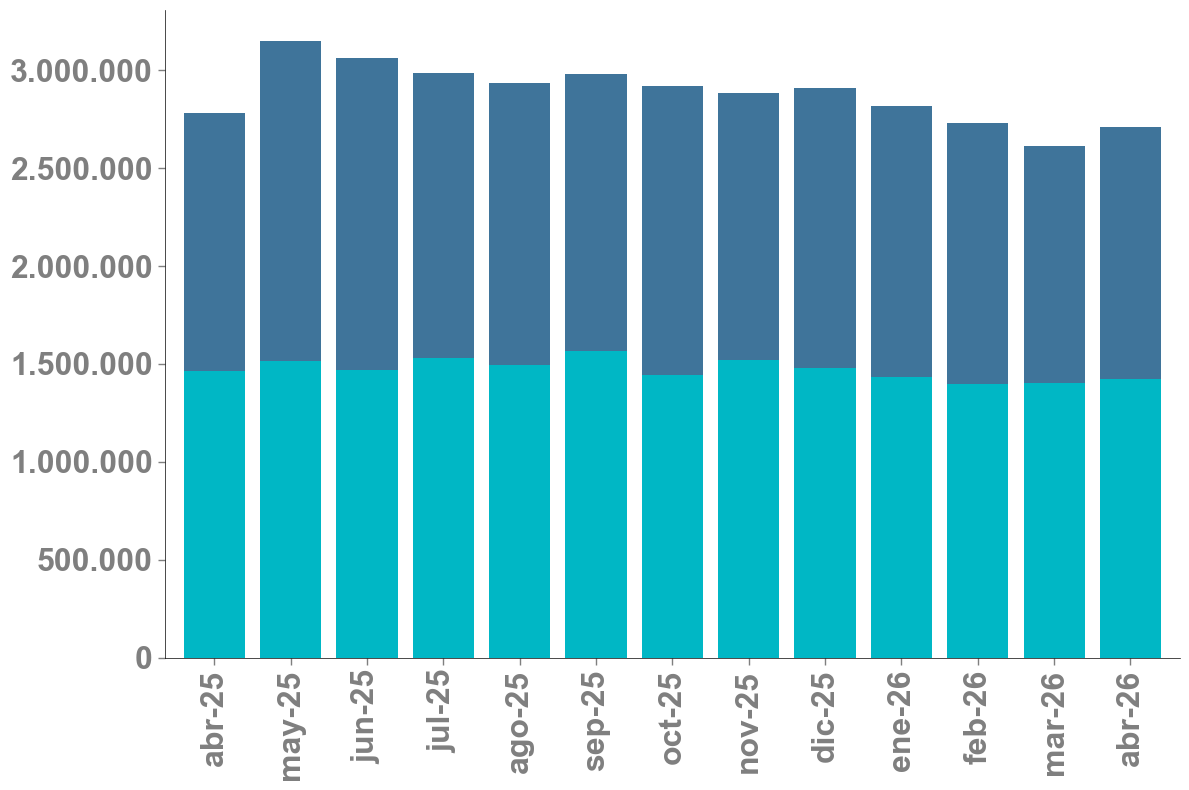

In [ ]:
# Crear figura y eje
fig, ax = plt.subplots(figsize=(12,8))

# Lista de meses en español
meses_esp = ['ene', 'feb', 'mar', 'abr', 'may', 'jun',
             'jul', 'ago', 'sep', 'oct', 'nov', 'dic']

df_grafico.index = [
    f"{meses_esp[d.month-1]}-{str(d.year)[-2:]}"
    for d in pd.to_datetime(df_grafico.index)
]

# Graficar barras apiladas con colores personalizados
df_grafico.plot(kind='bar', stacked=True, ax=ax,
                color=['#00B7C5','#3F749A'],
                width=0.8)

# Rotar etiquetas eje x
plt.xticks(rotation=90)


# Asignar etiquetas al eje x
#ax.set_xticklabels(fechas_esp, rotation=90)

# Quitar etiqueta del eje x
ax.set_xlabel('')

# Quitar recuadro (spines) superior y derecho
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Ajuste de ticks del eje x e y
ax.tick_params(axis='x', which='major',
               length=5, width=1,
               color='#7F7F7F')

ax.tick_params(axis='y', which='major',
               length=5, width=1,
               color='#7F7F7F',
               direction='out')

# Hacer líneas de los ejes más finas
ax.spines['left'].set_linewidth(0.5)
ax.spines['bottom'].set_linewidth(0.5)

# Cambiar fuente a Arial negrita tamaño 12 para ticks y títulos y color gris
for label in (ax.get_xticklabels() + ax.get_yticklabels()):
    label.set_fontname('Arial')
    label.set_fontweight('bold')
    label.set_fontsize(23)
    label.set_color('#7F7F7F')

# Cambiar fuente para etiqueta eje y
ax.yaxis.label.set_fontname('Arial')
ax.yaxis.label.set_fontweight('bold')
ax.yaxis.label.set_fontsize(23)
ax.yaxis.label.set_color('#7F7F7F')
ax.yaxis.set_major_formatter(
    ticker.FuncFormatter(lambda x, pos: f'{x:,.0f}'.replace(',', '.'))
)

# Formato eje y
for tick in ax.yaxis.get_major_ticks():
    tick.label1.set_fontname('Arial')
    tick.label1.set_fontsize(23)
    tick.label1.set_fontweight('bold')
    tick.label1.set_color('#7F7F7F')

plt.legend().remove()
plt.tight_layout()
plt.rcParams['pdf.fonttype'] = 42   # incrusta TrueType
plt.rcParams['ps.fonttype'] = 42
plt.rcParams['svg.fonttype'] = 'none'  # mantiene texto editable

plt.savefig(os.path.join(ruta_completa, '1. RP_RON_Total_barras_AA.png'),
            dpi=300,
            bbox_inches='tight')

plt.show()


#### Gráfico de líneas Total - Últimos 12 meses variación interanual


* Recursos Propios - YoY
* Recursos Origen Nacional - Yoy
* Recursos Totales

-----  *lista_0*  ------


C:\Users\janis\AppData\Local\Temp\ipykernel_14380\2563995778.py:97: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend().remove()


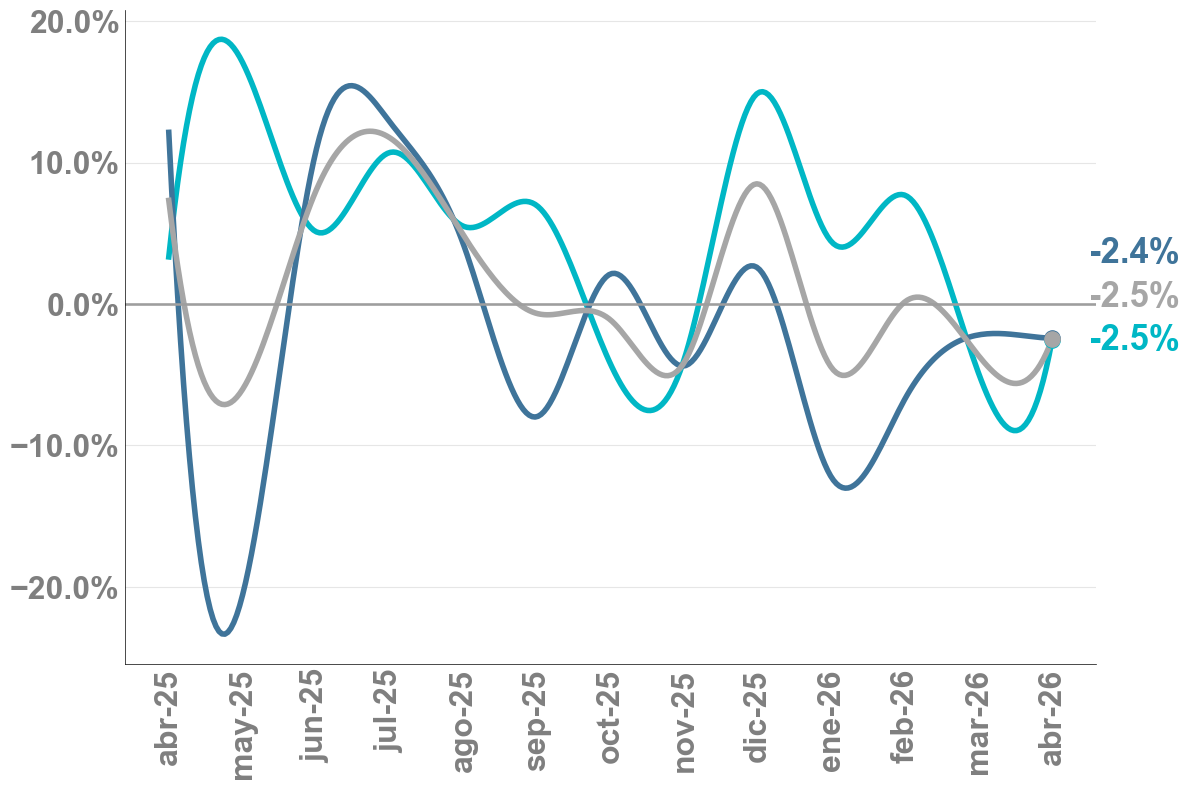

In [ ]:
# Últimos 12 meses variación interanual

df_vi = df_filtrado[lista_0].pct_change(12) * 100
df_vi = df_vi.tail(13)

# Índice numérico para suavizar
x = list(range(len(df_vi)))

# Crear figura
fig, ax = plt.subplots(figsize=(12,8))

colors = ['#00B7C5','#3F749A', '#A6A6A6']

# Obtener último valor de cada variable (asegurando escalar)
last_vals = [(col, float(df_vi[col].iloc[-1])) for col in lista_0]

# Ordenarlas de menor a mayor
last_vals_sorted = sorted(last_vals, key=lambda x: x[1])

# Crear diccionario: variable → posición vertical ordenada
rank_dict = {col: rank for rank, (col, _) in enumerate(last_vals_sorted)}

for i, col in enumerate(lista_0):

    y = df_vi[col].values.astype(float)  # asegura tipo numérico

    # -------- Suavizado --------
    x_new = np.linspace(min(x), max(x), 300)
    spline = make_interp_spline(x, y, k=3)
    y_smooth = spline(x_new)

    ax.plot(x_new, y_smooth, color=colors[i], linewidth=4)

    # Punto final SOBRE la curva suavizada
    ax.scatter(
        x_new[-1],
        y_smooth[-1],
        color=colors[i],
        s=120,
        zorder=5
    )

    # -------- Etiqueta último dato REAL --------
    last_x = x[-1]
    last_y = float(y[-1])

    # Offset dinámico según ranking
    offset = rank_dict[col] * 3

    ax.text(
        last_x + 0.5,
        last_y + offset,
        f"{last_y:.1f}%",
        color=colors[i],
        fontsize=25,
        fontweight='bold',
        fontname='Arial',
        va='center'
    )

# ------ Eje X: meses en español ------
meses_esp = ['ene', 'feb', 'mar', 'abr', 'may', 'jun',
             'jul', 'ago', 'sep', 'oct', 'nov', 'dic']

fechas_esp = [f"{meses_esp[d.month-1]}-{str(d.year)[-2:]}" for d in df_vi.index]

ax.set_xticks(x)
ax.set_xticklabels(fechas_esp, rotation=90)
ax.tick_params(axis='x', which='both', length=0)

# ------ Eje Y ------
import matplotlib.ticker as mtick
ax.yaxis.set_major_formatter(mtick.PercentFormatter())
ax.tick_params(axis='y', which='both', length=0)

# Bordes
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_linewidth(0.5)
ax.spines['bottom'].set_linewidth(0.5)

# Fuente
for label in (ax.get_xticklabels() + ax.get_yticklabels()):
    label.set_fontname('Arial')
    label.set_fontweight('bold')
    label.set_fontsize(23)
    label.set_color('#7F7F7F')

# Líneas base
ax.axhline(y=0, color='#9E9E9E', linewidth=1, zorder=0)
ax.axhline(0, color='#9E9E9E', linewidth=1.8)

# Grid
ax.grid(axis='y', color='#E6E6E6', linewidth=0.8)

ax.set_xlabel('')
plt.legend().remove()

plt.tight_layout()

# Export configs
plt.rcParams['pdf.fonttype'] = 42
plt.rcParams['ps.fonttype'] = 42
plt.rcParams['svg.fonttype'] = 'none'

plt.savefig(os.path.join(ruta_completa, '2. RP_RON_Total_lineas_AA.png'),
            dpi=300,
            bbox_inches='tight')

plt.show()

#### Gráfico de lineas comparativo último mes y año anterior (Var a/a)
* Total
* IIBB
* Inmobiliario
* Sellos
* Automotor
* Resto

-----  *lista_1*  ------

C:\Users\janis\AppData\Local\Temp\ipykernel_14380\4094475864.py:246: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend().remove()


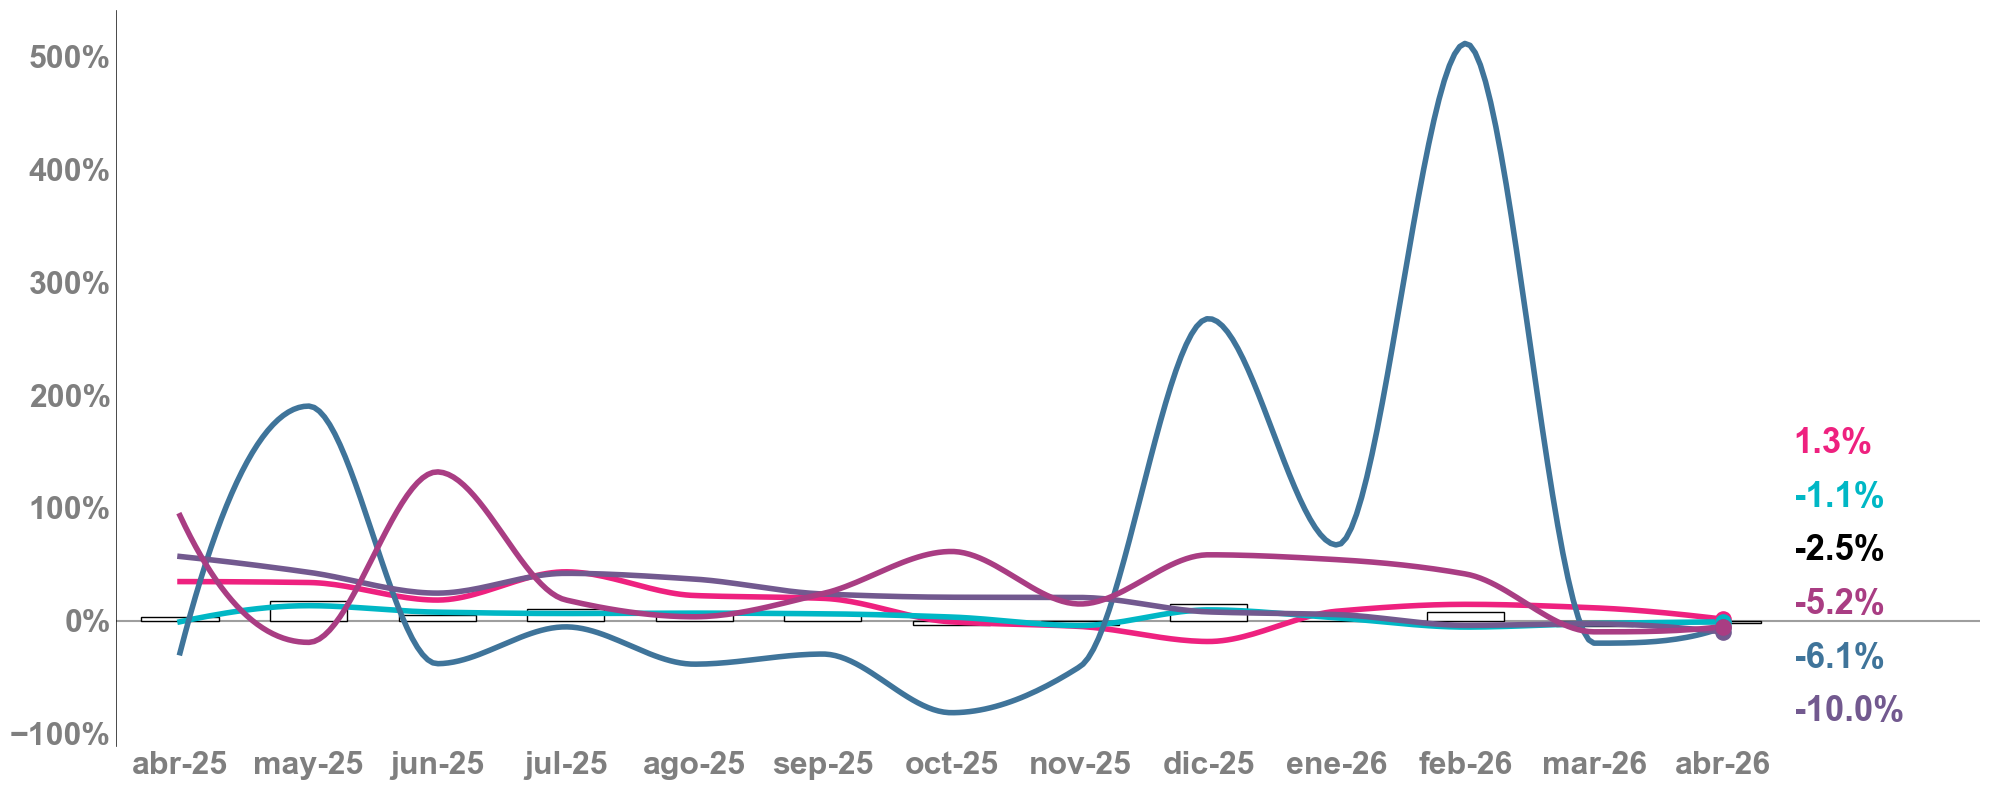

In [ ]:
# -----------------------------
# DATOS
# -----------------------------

from scipy.interpolate import PchipInterpolator

df_vi = df_filtrado[lista_1].pct_change(12) * 100
df_vi = df_vi.tail(13)

df_bar_tot = (
    fiscal_db['Total RP corriente_defl']
    .pct_change(12) * 100
)

df_bar_tot = df_bar_tot.tail(13)

df_bar_tot = df_bar_tot.loc[df_vi.index]

# -----------------------------
# EJE X
# -----------------------------

x = list(range(len(df_vi)))

# -----------------------------
# FIGURA
# -----------------------------

fig, ax = plt.subplots(figsize=(20, 8))

ax.set_xlim(-0.5, len(x) - 0.5 + 1.5)

# -----------------------------
# BARRAS
# -----------------------------

ax.bar(
    x,
    df_bar_tot.values,
    width=0.6,
    color="#ffffff",
    edgecolor='#000000',
    linewidth=1,
    zorder=1
)

# -----------------------------
# COLORES
# -----------------------------

color_dict = {
    'Automotor_defl': '#A93D83',
    'Sellos_defl': '#72598F',
    'IIBB_defl': '#00B7C5',
    'Inmobiliario_total_defl': '#3F749A',
    'Trans. Bs+FOPROVI+Imp. Energía+Planes_defl': '#EE217F'
}



# -----------------------------
# POSICIONES ETIQUETAS
# -----------------------------

last_vals = [
    (col, df_vi[col].values[-1], color_dict[col])
    for col in lista_1
]

bar_last = df_bar_tot.values[-1]

last_vals.append(
    ("TOTAL", bar_last, "#000000")
)

# ordenar de mayor a menor
last_vals_sorted = sorted(
    last_vals,
    key=lambda x: x[1],
    reverse=True
)

# valor más alto
base_y = max([
    v for _, v, _ in last_vals_sorted
])

# separación vertical
gap = (
    df_vi.max().max() -
    df_vi.min().min()
) * 0.08

# posiciones
positions = {
    name: base_y + 5 - (i * gap)
    for i, (name, _, _) in enumerate(last_vals_sorted)
}

# -----------------------------
# LINEAS SUAVIZADAS
# -----------------------------

for col in lista_1:

    y = df_vi[col].values.astype(float)

    x_new = np.linspace(
        min(x),
        max(x),
        300
    )

    # suavizado estilo Excel
    interp = PchipInterpolator(
        x,
        y
    )

    y_smooth = interp(x_new)

    # línea
    ax.plot(
        x_new,
        y_smooth,
        color=color_dict[col],
        linewidth=4,
        zorder=3
    )

    # punto final
    ax.scatter(
        x_new[-1],
        y_smooth[-1],
        color=color_dict[col],
        s=120,
        zorder=5
    )

    # último valor
    last_y = y[-1]

    # etiqueta final
    ax.text(
        x[-1] + 0.55,
        positions[col] + 165, # Luego del '+' sirve para ajustar la posición de las etiquetas
        f"{last_y:.1f}%",
        color=color_dict[col],
        fontsize=25,
        fontweight='bold',
        fontname='Arial',
        va='top'
    )

# -----------------------------
# ETIQUETA TOTAL
# -----------------------------

ax.text(
    x[-1] + 0.55,
    positions["TOTAL"] + 165, # Luego del '+' sirve para ajustar la posición de las etiquetas
    f"{bar_last:.1f}%",
    color="#000000",
    fontsize=25,
    fontweight='bold',
    fontname='Arial',
    va='top'
)

# -----------------------------
# EJE X
# -----------------------------

meses_esp = [
    'ene', 'feb', 'mar', 'abr', 'may', 'jun',
    'jul', 'ago', 'sep', 'oct', 'nov', 'dic'
]

fechas_esp = [
    f"{meses_esp[d.month-1]}-{str(d.year)[-2:]}"
    for d in df_vi.index
]

ax.set_xticks(x)

ax.set_xticklabels(
    fechas_esp,
    rotation=0
)

ax.tick_params(
    axis='x',
    length=0
)

# -----------------------------
# EJE Y
# -----------------------------

ax.yaxis.set_major_formatter(
    mtick.PercentFormatter()
)

ax.tick_params(
    axis='y',
    length=0
)

# -----------------------------
# ESTILO
# -----------------------------

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

ax.spines['left'].set_linewidth(0.5)
ax.spines['bottom'].set_visible(False)

for label in (
    ax.get_xticklabels() +
    ax.get_yticklabels()
):

    label.set_fontname('Arial')
    label.set_fontweight('bold')
    label.set_fontsize(23)
    label.set_color('#7F7F7F')

# -----------------------------
# LINEA CERO
# -----------------------------

ax.axhline(
    0,
    color='#9E9E9E',
    linewidth=1.5,
    zorder=0
)

# -----------------------------
# LIMPIEZA
# -----------------------------

ax.set_xlabel('')

plt.legend().remove()

plt.tight_layout()

# -----------------------------
# EXPORT
# -----------------------------

plt.rcParams['pdf.fonttype'] = 42
plt.rcParams['ps.fonttype'] = 42
plt.rcParams['svg.fonttype'] = 'none'

plt.savefig(
    os.path.join(
        ruta_completa,
        '3. Desagregado_lineas_AA.png'
    ),
    dpi=300,
    bbox_inches='tight'
)

plt.show()

#### Gráfico de barras último valor y el del año anterior:
* Total
* IIBB
* Inmobiliario
* Automotor
* Sellos
* Resto

-----  *lista_2*  ------

-----  *etiquetas_2*  -----

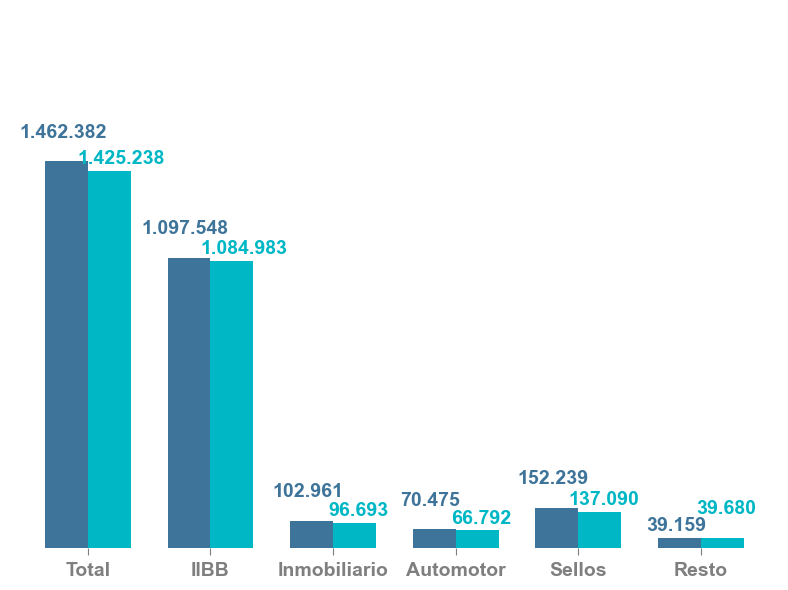

In [ ]:
# -----------------------------
# Seleccionar último mes y año anterior
# -----------------------------

ultimo_mes = df_filtrado.iloc[-1]
año_anterior = df_filtrado.iloc[-13]

val_ultimo = ultimo_mes[lista_2].values
val_anterior = año_anterior[lista_2].values

x = np.arange(len(lista_2))
ancho = 0.35

# -----------------------------
# Escala
# -----------------------------

ymax = max(val_ultimo.max(), val_anterior.max())
y_base = -ymax * 0.04
gap = ymax * 0.02
min_sep = ymax * 0.05

# -----------------------------
# Figura
# -----------------------------

fig, ax = plt.subplots(figsize=(8, 6))

# -----------------------------
# Barras
# -----------------------------

barras1 = ax.bar(
    x - ancho/2,
    val_anterior,
    width=ancho,
    bottom=y_base,
    color='#3F749A'
)

barras2 = ax.bar(
    x + ancho/2,
    val_ultimo,
    width=ancho,
    bottom=y_base,
    color='#00B7C5'
)

# -----------------------------
# Límites
# -----------------------------

ax.set_ylim(y_base, ymax * 1.35)
ax.margins(y=0)

# -----------------------------
# Ejes
# -----------------------------

ax.set_yticks([])

for side in ['left', 'bottom', 'right', 'top']:
    ax.spines[side].set_visible(False)

ax.tick_params(axis='x', length=5, pad=5, colors='#7F7F7F')

# -----------------------------
# Etiquetas eje X
# -----------------------------

ax.set_xticks(x)

ax.set_xticklabels(etiquetas_2)

for label in ax.get_xticklabels():
    label.set_fontname('Arial')
    label.set_fontweight('bold')
    label.set_fontsize(14)
    label.set_color('#7F7F7F')

# -----------------------------
# Brackets
# -----------------------------

tick_height = ymax * 0.1

for i in range(len(x)):

    h1 = val_anterior[i]
    h2 = val_ultimo[i]

    y1 = y_base + h1
    y2 = y_base + h2

    offset1 = gap
    offset2 = gap

    if abs(y1 - y2) < min_sep:

        if h1 >= h2:
            offset1 = min_sep
            offset2 = min_sep * 0.15
        else:
            offset1 = min_sep * 0.15
            offset2 = min_sep

    ax.text(
        x[i] - ancho/2 - 0.03,
        y1 + offset1,
        f'{h1:,.0f}'.replace(',', '.'),
        ha='center',
        va='bottom',
        fontsize=14,
        fontname='Arial',
        color='#3F749A',
        fontweight='bold'
    )

    x_pos = x[i] + ancho/2 + (0.03 if h2 < 1000000 else 0.1)

    ax.text(
        x_pos,
        y2 + offset2,
        f'{h2:,.0f}'.replace(',', '.'),
        ha='center',
        va='bottom',
        fontsize=14,
        fontname='Arial',
        color='#00B7C5',
        fontweight='bold'
    )
"""
# -----------------------------
# Leyenda
# -----------------------------

fecha_actual = fiscal_db.index[-1]
fecha_anterior = fiscal_db.index[-13]

label_actual = fecha_actual.strftime('%b-%y').lower()
label_anterior = fecha_anterior.strftime('%b-%y').lower()

legend_elements = [
    Patch(facecolor='#3F749A', label=label_anterior),
    Patch(facecolor='#00B7C5', label=label_actual)
]

leg = ax.legend(
    handles=legend_elements,
    loc='upper right',
    bbox_to_anchor=(0.98, 0.85),
    frameon=False,
    fontsize=14,
    ncol=2,
    handlelength=1,
    handleheight=1,
    columnspacing=1.5
)

for text in leg.get_texts():
    text.set_fontname('Arial')
    text.set_fontweight('bold')
    text.set_color('#7F7F7F')
"""
# -----------------------------
# Export
# -----------------------------

plt.tight_layout()

plt.savefig(
    os.path.join(ruta_completa, '4. Desagregado_ult_ant_barras.png'),
    dpi=300,
    bbox_inches='tight'
)

plt.show()

#### Gráfico de barras horizontales con eje centrado YoY:
* Total
* IIBB
* Inmobiliario
* Automotor
* Sellos
* Resto

-----  *lista_3*  ------

-----   *etiquetas_3* -----

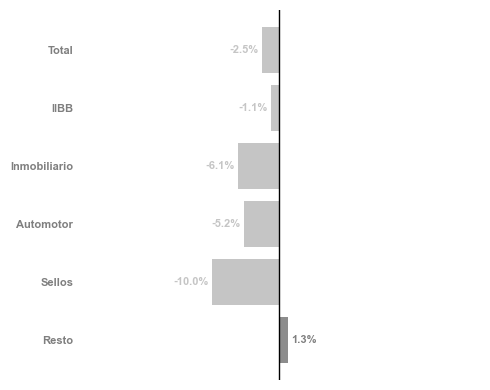

In [ ]:

df_vi = df_filtrado[lista_3].pct_change(12) * 100

# Reemplazar NaN (cuando no hay dato previo) por -100
df_vi = df_vi.fillna(-100)

# Convertir variación en vector
variacion = df_vi.tail(1).values.flatten()

# Crear figura
fig, ax = plt.subplots(figsize=(5, 4))

# Crear colores según signo
colores = ["#8C8C8C" if v > 0 else "#C5C5C5" for v in variacion]

# Posiciones en eje Y
y = range(len(etiquetas_3))

# Barras
ax.barh(
    y,
    variacion,
    color=colores
)

# Línea vertical en cero
ax.axvline(0, color='black', linewidth=1)

# hacer barras más cortas
max_val = max(abs(variacion))
ax.set_xlim(-max_val*3, max_val*3)

# Etiquetas a la izquierda
ax.set_yticks(y)
ax.tick_params(axis='y', length=0)
ax.set_yticklabels(etiquetas_3,
                   fontname="Arial",
                   fontsize=8,
                   color="#7F7F7F",
                   fontweight='bold')

# Ocultar bordes
for spine in ax.spines.values():
    spine.set_visible(False)

# Grid vertical
ax.xaxis.grid(False)

# Ocultar el eje x
ax.get_xaxis().set_visible(False)

# Texto de valores
for i, v in enumerate(variacion):

    if v > 0:
        color = "#7F7F7F"
    else:
        color = "#C5C5C5"

    ax.text(
        v + (0.5 if v >= 0 else -0.5),
        i,
        f"{v:.1f}%",
        ha='left' if v >= 0 else 'right',
        va='center',
        fontname='Arial',
        fontsize=8,
        color=color,
        fontweight="bold"
    )
# Quitar etiquetas de ejes
ax.set_xlabel("")
ax.set_ylabel("")

plt.savefig(os.path.join(ruta_completa, '5. Desagregado_barras_hor_AA.png'),
            dpi=300,
            bbox_inches='tight')

plt.tight_layout()
plt.show()


#### Gráfico de barras Acumulado - último valor y el del año anterior:
* Total
* IIBB
* Inmobiliario
* Automotor
* Sellos
* Resto

-----  *lista_4*  ------

-----  *etiquetas_2* -----

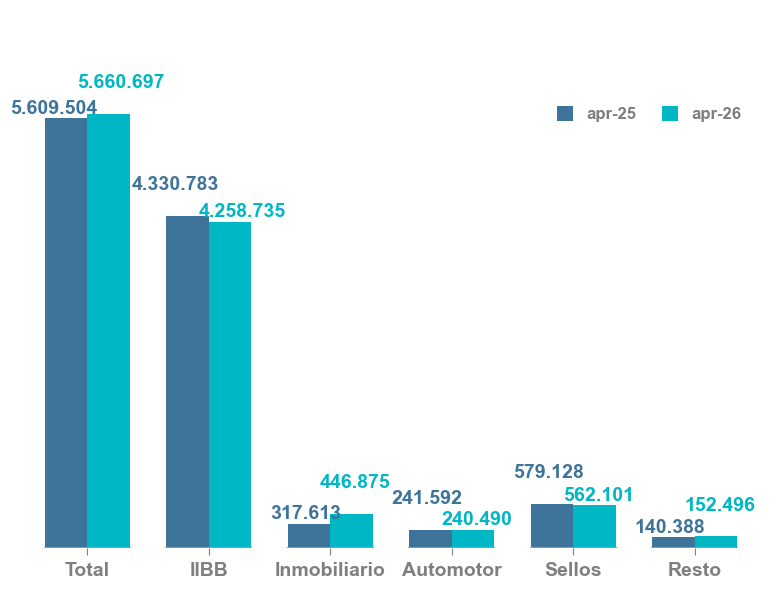

In [ ]:
# -----------------------------
# Seleccionar último mes y año anterior
# -----------------------------
ultimo_mes = df_filtrado.iloc[-1]
año_anterior = df_filtrado.iloc[-13]


val_ultimo = ultimo_mes[lista_4_0].values
val_anterior = año_anterior[lista_4_0].values

x = np.arange(len(etiquetas_2))
ancho = 0.35
# -----------------------------
# Escala
# -----------------------------
ymax = max(val_ultimo.max(), val_anterior.max())
y_base = -ymax * 0.04
gap = ymax * 0.02

# -----------------------------
# Figura
# -----------------------------
fig, ax = plt.subplots(figsize=(8, 6))

# -----------------------------
# Barras (alineadas al eje)
# -----------------------------
barras1 = ax.bar(
    x - ancho/2,
    val_anterior,
    width=ancho,
    bottom=y_base,
    color='#3F749A'
)

barras2 = ax.bar(
    x + ancho/2,
    val_ultimo,
    width=ancho,
    bottom=y_base,
    color='#00B7C5'
)

# -----------------------------
# Límites
# -----------------------------
ax.set_ylim(y_base, ymax * 1.2)
ax.margins(y=0)

# -----------------------------
# Quitar ejes
# -----------------------------
ax.set_yticks([])
for side in ['left', 'bottom', 'right', 'top']:
    ax.spines[side].set_visible(False)

ax.tick_params(axis='x', length=5, pad=5, colors='#7F7F7F')

# -----------------------------
# Etiquetas eje X
# -----------------------------
ax.set_xticks(x)
ax.set_xticklabels(etiquetas_2)

for label in ax.get_xticklabels():
    label.set_fontname('Arial')
    label.set_fontweight('bold')
    label.set_fontsize(14)
    label.set_color('#7F7F7F')

# -----------------------------
# Brackets
# -----------------------------
tick_height = ymax * 0.1

for i in range(len(x)):
    left = x[i] - ancho
    right = x[i] + ancho

    ax.plot([left, right], [y_base, y_base], color='#9E9E9E', linewidth=1.3)
    ax.plot([left, left], [y_base, y_base - tick_height], color='#9E9E9E', linewidth=1.3)
    ax.plot([right, right], [y_base, y_base - tick_height], color='#9E9E9E', linewidth=1.3)

# -----------------------------
# Etiquetas
# -----------------------------

min_sep = ymax * 0.05

for i in range(len(x)):

    h1 = val_anterior[i]
    h2 = val_ultimo[i]

    y1 = y_base + h1
    y2 = y_base + h2

    offset1 = gap
    offset2 = gap

    if abs(y1 - y2) < min_sep:

        if h1 >= h2:
            offset1 = min_sep
            offset2 = min_sep * 0.02
        else:
            offset1 = min_sep * 0.02
            offset2 = min_sep

    y1_label = y1 + offset1
    y2_label = y2 + offset2

    x_pos_1 = x[i] - ancho/2 - (0.03 if h1 < 1000000 else 0.1)

    ax.text(
        x_pos_1,
        y1_label,
        f'{h1:,.0f}'.replace(',', '.'),
        ha='center',
        va='bottom',
        fontsize=14,
        fontname='Arial',
        color='#3F749A',
        fontweight='bold'
    )

    x_pos_2 = x[i] + ancho/2 + (0.03 if h2 < 1000000 else 0.1)

    ax.text(
        x_pos_2,
        y2_label,
        f'{h2:,.0f}'.replace(',', '.'),
        ha='center',
        va='bottom',
        fontsize=14,
        fontname='Arial',
        color='#00B7C5',
        fontweight='bold'
    )

# -----------------------------
# Layout
# -----------------------------
fecha_actual = fiscal_db.index[-1]
fecha_anterior = fiscal_db.index[-13]

label_actual = fecha_actual.strftime('%b-%y').lower()
label_anterior = fecha_anterior.strftime('%b-%y').lower()

legend_elements = [
    Patch(facecolor='#3F749A', label=label_anterior),
    Patch(facecolor='#00B7C5', label=label_actual)
]

leg = ax.legend(
    handles=legend_elements,
    loc='upper right',
    bbox_to_anchor=(0.98, 0.85),
    frameon=False,
    fontsize=12,
    ncol=2,
    handlelength=1,
    handleheight=1,
    columnspacing=1.5
)

# estilo
for text in leg.get_texts():
    text.set_fontname('Arial')
    text.set_fontweight('bold')
    text.set_color('#7F7F7F')

plt.savefig(os.path.join(ruta_completa, '6. Desagregado_ult_ant_barras_Acum.png'),
            dpi=300,
            bbox_inches='tight')


plt.tight_layout()
plt.show()

#### Gráfico de barras horizontales con eje centrado Acumualado YoY:
* Total
* IIBB
* Inmobiliario
* Automotor
* Sellos
* Resto

-----  *lista_4*  -----

-----  *etiquetas_5*  -----

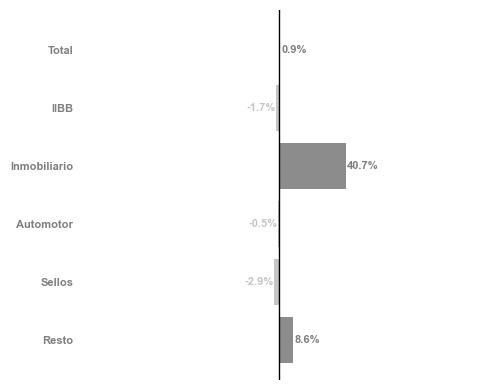

In [ ]:
df_vi = df_filtrado[lista_4].pct_change(12) * 100

df_vi = df_vi.fillna(-100)

# Convertir variación en vector
variacion = df_vi.tail(1).values.flatten()

# Crear figura
fig, ax = plt.subplots(figsize=(5, 4))

# Posiciones
y = np.arange(len(etiquetas_3))

# Crear colores según signo
colores = ["#8C8C8C" if v > 0 else "#C5C5C5" for v in variacion]

# Barras
ax.barh(
    y,
    variacion,
    color=colores
)

# Línea vertical en cero
ax.axvline(0, color='black', linewidth=1)

# hacer barras más cortas
max_val = max(abs(variacion))
ax.set_xlim(-max_val*3, max_val*3)

# Etiquetas a la izquierda
ax.set_yticks(y)
ax.tick_params(axis='y', length=0)
ax.set_yticklabels(etiquetas_3,
                   fontname="Arial",
                   fontsize=8,
                   color="#7F7F7F",
                   fontweight='bold')

# Ocultar bordes
for spine in ax.spines.values():
    spine.set_visible(False)

# Grid vertical
ax.xaxis.grid(False)

# Ocultar el eje x
ax.get_xaxis().set_visible(False)

# Texto de valores
for i, v in enumerate(variacion):

    if v > 0:
        color = "#7F7F7F"
    else:
        color = "#C5C5C5"

    ax.text(
        v + (0.5 if v >= 0 else -0.5),
        i,
        f"{v:.1f}%",
        ha='left' if v >= 0 else 'right',
        va='center',
        fontname='Arial',
        fontsize=8,
        color=color,
        fontweight="bold"
    )

# Quitar etiquetas de ejes
ax.set_xlabel("")
ax.set_ylabel("")

plt.savefig(os.path.join(ruta_completa, '7. Desagregado_barras_hor_AcumAA.png'),
            dpi=300,
            bbox_inches='tight')

plt.tight_layout()
plt.show()

#### Gráfico de lineas var a/a 'Copa + Fin. Edu' y Resto, junto con gráfico de barras var a/a Total

* Copa. + Fin Edu
* Resto
* Total


C:\Users\janis\AppData\Local\Temp\ipykernel_14380\1549186213.py:160: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend().remove()


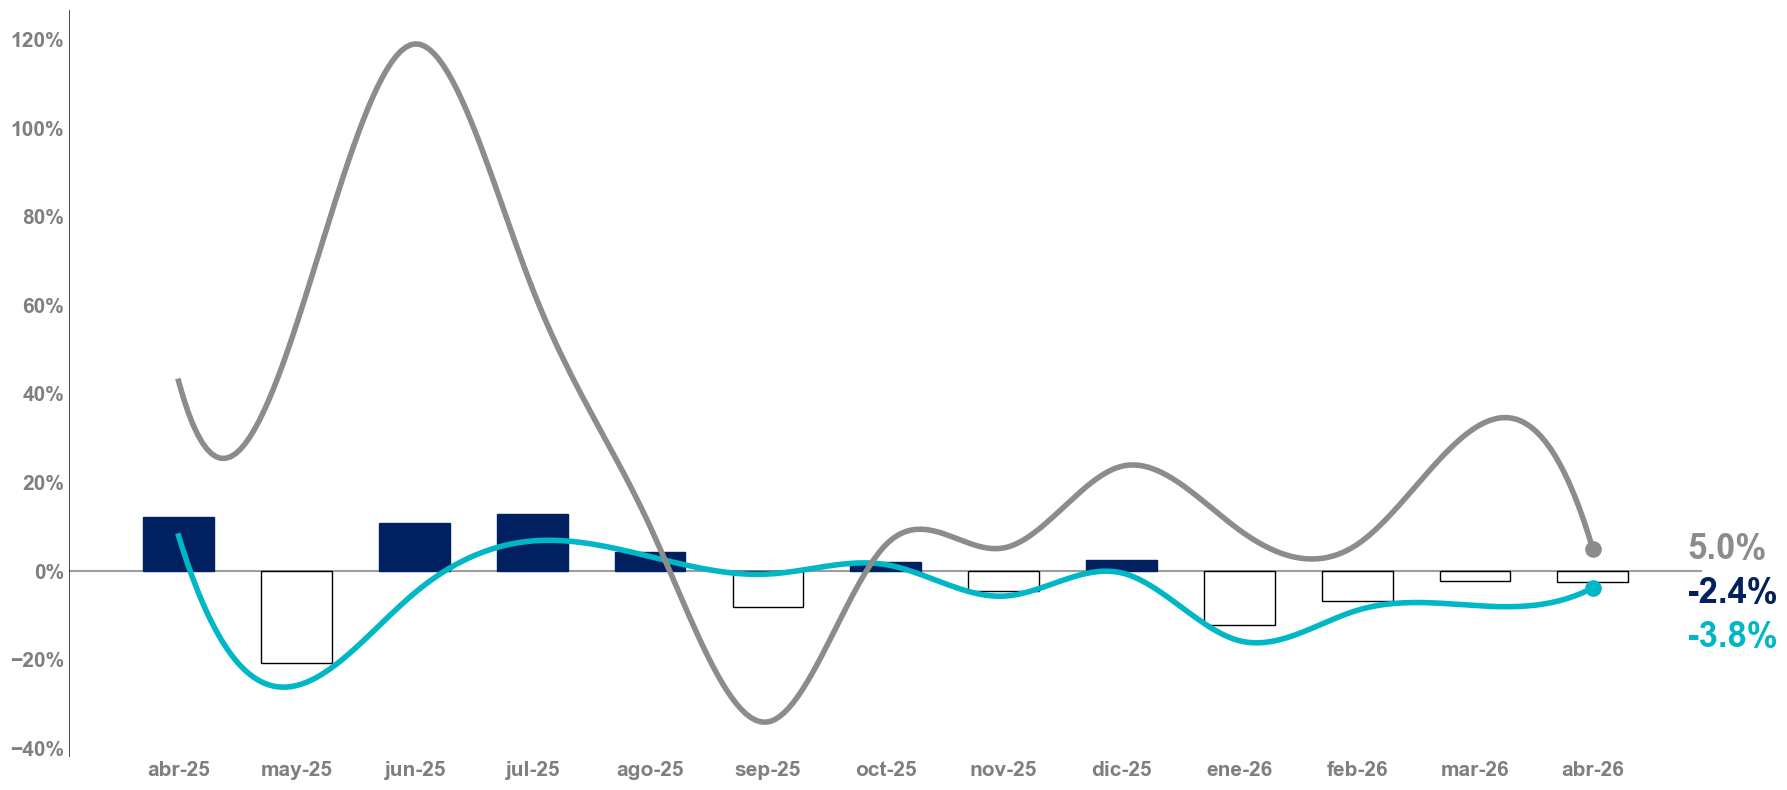

In [ ]:
# -----------------------------
# VARIABLES
# -----------------------------
variables = ['Copa + Ley_defl','Resto + Tr_ss_defl']

df_vi = df_filtrado[variables].pct_change(12) * 100
df_vi = df_vi.tail(13)

df_bar = fiscal_db['Total RON corriente_defl'].pct_change(12) * 100
df_bar = df_bar.tail(13)

x = list(range(len(df_vi)))

# -----------------------------
# COLORES
# -----------------------------
colors = ['#00B7C5','#8C8C8C']

colores_barra = ["#002060" if v > 0 else "#FFFFFF" for v in df_bar.values]
bordes_barra = ["#002060" if v > 0 else "#000000" for v in df_bar.values]

# -----------------------------
# FIGURA
# -----------------------------
fig, ax = plt.subplots(figsize=(18,8))

# -----------------------------
# BARRAS
# -----------------------------
ax.bar(
    x,
    df_bar.values,
    width=0.6,
    color=colores_barra,
    edgecolor=bordes_barra,
    linewidth=1,
    zorder=1
)

# -----------------------------
# LINEAS
# -----------------------------
for i, col in enumerate(variables):

    y = df_vi[col].values

    x_new = np.linspace(min(x), max(x), 300)
    spline = make_interp_spline(x, y, k=3)
    y_smooth = spline(x_new)

    ax.plot(
        x_new,
        y_smooth,
        color=colors[i],
        linewidth=4,
        zorder=3
    )

    # Punto final SOBRE la curva suavizada
    ax.scatter(
        x_new[-1],
        y_smooth[-1],
        color=colors[i],
        s=120,
        zorder=5
    )

# -----------------------------
# RANKING (INCLUYE BARRA)
# -----------------------------
last_vals = [(col, df_vi[col].values[-1], colors[i]) for i, col in enumerate(variables)]

bar_last = df_bar.values[-1]
last_vals.append(("TOTAL", bar_last, "#002060"))

# ordenar
last_vals_sorted = sorted(last_vals, key=lambda x: x[1], reverse=True)

# posiciones verticales
last_vals_sorted = sorted(last_vals, key=lambda x: x[1], reverse=True)

top = max(v for _, v, _ in last_vals_sorted)

# gap fijo (independiente de datos)
gap = 10

positions = {
    name: top - i * gap
    for i, (name, _, _) in enumerate(last_vals_sorted)
}

base_y = max(v for _, v, _ in last_vals_sorted)

positions = {
    name: base_y - i * gap
    for i, (name, _, _) in enumerate(last_vals_sorted)
}

# -----------------------------
# ETIQUETAS ALINEADAS
# -----------------------------
label_x = x[-1] + 0.8

for name, value, color in last_vals_sorted:

    ax.text(
        label_x,
        positions[name],
        f"{value:.1f}%",
        color=color,
        fontsize=25,
        fontweight='bold',
        fontname='Arial',
        va='center'
    )

# -----------------------------
# EJE X
# -----------------------------
meses_esp = ['ene', 'feb', 'mar', 'abr', 'may', 'jun',
             'jul', 'ago', 'sep', 'oct', 'nov', 'dic']

fechas_esp = [
    f"{meses_esp[d.month-1]}-{str(d.year)[-2:]}"
    for d in df_vi.index
]

ax.set_xticks(x)
ax.set_xticklabels(fechas_esp, rotation=0)


ax.tick_params(axis='x', length=0)

# -----------------------------
# EJE Y
# -----------------------------
ax.yaxis.set_major_formatter(mtick.PercentFormatter())
ax.tick_params(axis='y', length=0)

# -----------------------------
# ESTILO
# -----------------------------
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_linewidth(0.5)
ax.spines['bottom'].set_linewidth(False)

for label in (ax.get_xticklabels() + ax.get_yticklabels()):
    label.set_fontname('Arial')
    label.set_fontweight('bold')
    label.set_fontsize(15)
    label.set_color('#7F7F7F')

ax.axhline(0, color='#9E9E9E', linewidth=1.5, zorder=0)

# -----------------------------
# LIMPIEZA FINAL
# -----------------------------
ax.set_xlabel('')
plt.legend().remove()

plt.tight_layout()

plt.rcParams['pdf.fonttype'] = 42
plt.rcParams['ps.fonttype'] = 42
plt.rcParams['svg.fonttype'] = 'none'

plt.savefig(os.path.join(ruta_completa, '8. Copa_Resto_Total_lineas_AA.png'),
            dpi=300,
            bbox_inches='tight')

plt.show()

#### Gráfico de barras último valor y el del año anterior:
* Total RON
* Copart. + Ley de Fin. Educativo
* Resto de tributos

-----  *lista_5*  ------

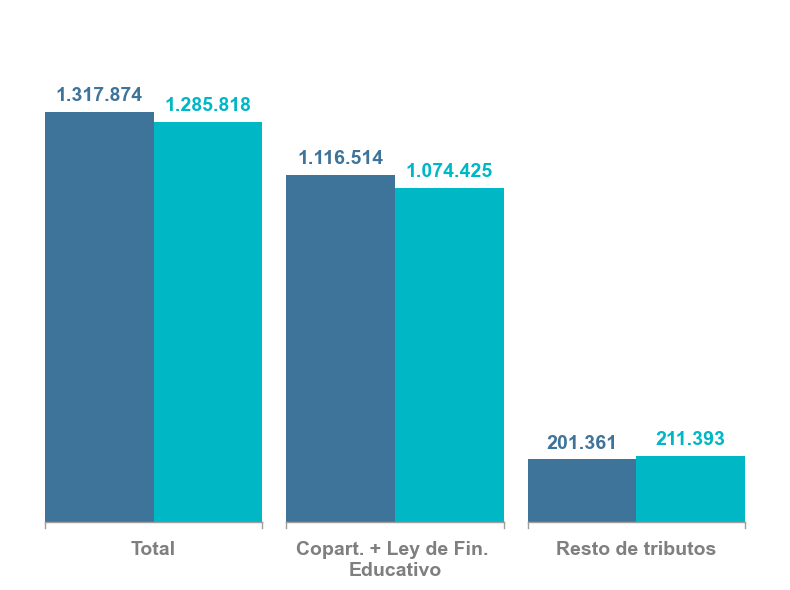

In [ ]:
fecha_actual = fiscal_db[
    (fiscal_db.index.year == ANIO) &
    (fiscal_db.index.month == MES)
]

fecha_anterior = fiscal_db[
    (fiscal_db.index.year == ANIO - 1) &
    (fiscal_db.index.month == MES)
]

val_ultimo = fecha_actual[lista_5].values.flatten()
val_anterior = fecha_anterior[lista_5].values.flatten()

import numpy as np
import matplotlib.pyplot as plt

x = np.arange(len(lista_5))
ancho = 0.45

fig, ax = plt.subplots(figsize=(8,6))

barras1 = ax.bar(
    x - ancho/2,
    val_anterior,
    width=ancho,
    color='#3F749A'
)

barras2 = ax.bar(
    x + ancho/2,
    val_ultimo,
    width=ancho,
    color='#00B7C5'
)

# -----------------------------
# Etiquetas sobre barras
# -----------------------------
offset_pixels_barra1 = 5
offset_pixels_barra2 = 5

for b in barras1:

    height = b.get_height()

    trans = transforms.ScaledTranslation(
        0,
        offset_pixels_barra1/72,
        fig.dpi_scale_trans
    )

    ax.text(
        b.get_x() + b.get_width()/2,
        height,
        f'{height:,.0f}'.replace(',', '.'),
        transform=ax.transData + trans,
        ha='center',
        va='bottom',
        fontsize=14,
        fontname='Arial',
        color='#3F749A',
        fontweight='bold'
    )

for b in barras2:

    height = b.get_height()

    trans = transforms.ScaledTranslation(
        0,
        offset_pixels_barra2/72,
        fig.dpi_scale_trans
    )

    ax.text(
        b.get_x() + b.get_width()/2,
        height,
        f'{height:,.0f}'.replace(',', '.'),
        transform=ax.transData + trans,
        ha='center',
        va='bottom',
        fontsize=14,
        fontname='Arial',
        color='#00B7C5',
        fontweight='bold'
    )


# límites
ymax = max(val_ultimo.max(), val_anterior.max())
ax.set_ylim(-ymax*0.04, ymax*1.25)

# quitar ejes
ax.set_yticks([])
ax.spines['left'].set_visible(False)
ax.spines['bottom'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)

ax.tick_params(axis='x', length=0)

# -----------------------------
# Línea inferior con brackets
# -----------------------------
y_base = 0
tick_height = ymax * 0.015

for i in range(len(x)):

    left = x[i] - ancho
    right = x[i] + ancho

    # línea horizontal
    ax.plot(
        [left, right],
        [y_base, y_base],
        color='#9E9E9E',
        linewidth=1
    )

    # tick izquierdo
    ax.plot(
        [left, left],
        [y_base, y_base - tick_height],
        color='#9E9E9E',
        linewidth=1
    )

    # tick derecho
    ax.plot(
        [right, right],
        [y_base, y_base - tick_height],
        color='#9E9E9E',
        linewidth=1
    )

# etiquetas eje x
ax.set_xticks(x)

ax.set_xticklabels(
[
    'Total',
    'Copart. + Ley de Fin. \nEducativo',
    'Resto de tributos'
],
fontname='Arial',
fontweight='bold',
fontsize=14,
color='#7F7F7F'
)

# acercar etiquetas al eje
ax.tick_params(axis='x', pad=2)

plt.savefig(os.path.join(ruta_completa, '9. Copa_Resto_Total_ult_ant_barras.png'),
            dpi=300,
            bbox_inches='tight')

plt.tight_layout()
plt.show()

#### Gráfico de barras horizontales con eje centrado YoY:
* Total RON
* Copart. + Ley de Fin. Educativo
* Resto de tributos

-----  *lista_6*  ------

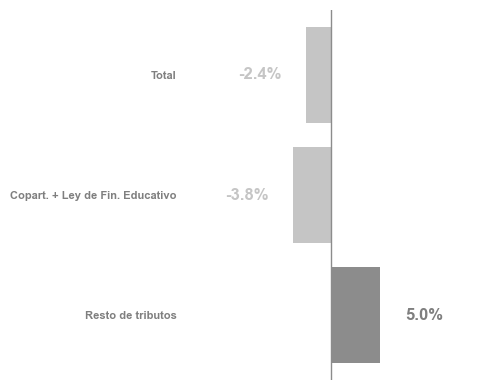

In [ ]:
# Categorías correctas (coinciden con las columnas)

categorias = ['Resto de tributos','Copart. + Ley de Fin. Educativo','Total']

df_vi = df_filtrado[lista_6].pct_change(12) * 100

# Convertir variación en vector
variacion = df_vi.tail(1).values.flatten()

# Crear figura
fig, ax = plt.subplots(figsize=(5, 4))

# Posiciones
y = np.arange(len(categorias))

# Crear colores según signo
colores = ["#8C8C8C" if v > 0 else "#C5C5C5" for v in variacion]

# Barras
ax.barh(
    y,
    variacion,
    color=colores
)

# Línea vertical en cero
ax.axvline(0, color='#8C8C8C', linewidth=1)

# hacer barras más cortas
max_val = max(abs(variacion))
ax.set_xlim(-max_val*3, max_val*3)

# Etiquetas a la izquierda
ax.set_yticks(y)
ax.set_yticklabels(categorias, fontname="Arial", fontsize=8, color="#7F7F7F", fontweight='bold')
ax.tick_params(axis='y', length=0)


# Ocultar bordes
for spine in ax.spines.values():
    spine.set_visible(False)

# Grid vertical
ax.xaxis.grid(False)

# Ocultar el eje x
ax.get_xaxis().set_visible(False)

# Texto de valores

offset = max_val * 0.5

for i, v in enumerate(variacion):

    if v > 0:
        color = "#7F7F7F"
    else:
        color = "#C5C5C5"

    ax.text(
        v + (offset if v >= 0 else -offset),
        i,
        f"{v:.1f}%",
        ha='left' if v >= 0 else 'right',
        va='center',
        fontname='Arial',
        fontsize=12,
        color=color,
        fontweight="bold"
    )

# Quitar etiquetas de ejes
ax.set_xlabel("")
ax.set_ylabel("")

plt.savefig(os.path.join(ruta_completa, '10. Copa_Resto_Total_barras_hor_AA.png'),
            dpi=300,
            bbox_inches='tight')

plt.tight_layout()
plt.show()

#### Gráfico de barras acumulado último valor y valor del año anterior:
* Total RON
* Copart. + Ley de Fin. Educativo
* Resto de tributos


-----  *lista_7*  ------

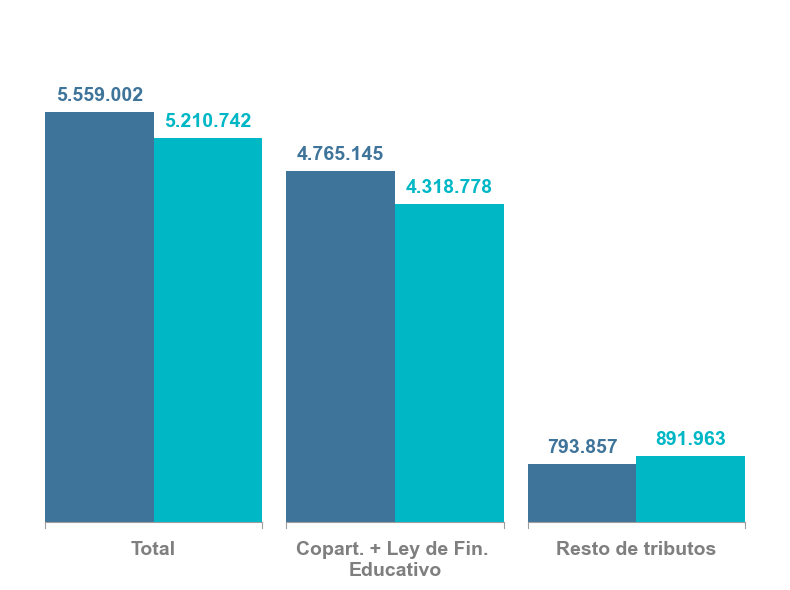

In [ ]:
# =========================
# VALORES (CLAVE: iloc[0])
# =========================
val_ultimo = fecha_actual[lista_7].iloc[0].values
val_anterior = fecha_anterior[lista_7].iloc[0].values

# =========================
# EJE X
# =========================
x = np.arange(len(lista_7))
ancho = 0.45

fig, ax = plt.subplots(figsize=(8,6))

# =========================
# BARRAS
# =========================
barras1 = ax.bar(
    x - ancho/2,
    val_anterior,
    width=ancho,
    color='#3F749A'
)

barras2 = ax.bar(
    x + ancho/2,
    val_ultimo,
    width=ancho,
    color='#00B7C5'
)

# =========================
# ETIQUETAS SOBRE BARRAS
# =========================
offset_pixels_barra1 = 5
offset_pixels_barra2 = 5

for b in barras1:
    height = b.get_height()

    trans = transforms.ScaledTranslation(
        0,
        offset_pixels_barra1/72,
        fig.dpi_scale_trans
    )

    ax.text(
        b.get_x() + b.get_width()/2,
        height,
        f'{height:,.0f}'.replace(',', '.'),
        transform=ax.transData + trans,
        ha='center',
        va='bottom',
        fontsize=14,
        fontname='Arial',
        color='#3F749A',
        fontweight='bold'
    )

for b in barras2:
    height = b.get_height()

    trans = transforms.ScaledTranslation(
        0,
        offset_pixels_barra2/72,
        fig.dpi_scale_trans
    )

    ax.text(
        b.get_x() + b.get_width()/2,
        height,
        f'{height:,.0f}'.replace(',', '.'),
        transform=ax.transData + trans,
        ha='center',
        va='bottom',
        fontsize=14,
        fontname='Arial',
        color='#00B7C5',
        fontweight='bold'
    )

# =========================
# LÍMITES
# =========================
ymax = max(val_ultimo.max(), val_anterior.max())
ax.set_ylim(-ymax*0.04, ymax*1.25)

# =========================
# LIMPIEZA DE EJES
# =========================
ax.set_yticks([])
ax.spines['left'].set_visible(False)
ax.spines['bottom'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)

ax.tick_params(axis='x', length=0)

# =========================
# BRACKETS
# =========================
y_base = 0
tick_height = ymax * 0.015

for i in range(len(x)):

    left = x[i] - ancho
    right = x[i] + ancho

    ax.plot([left, right], [y_base, y_base], color='#9E9E9E', linewidth=0.8)
    ax.plot([left, left], [y_base, y_base - tick_height], color='#9E9E9E', linewidth=0.8)
    ax.plot([right, right], [y_base, y_base - tick_height], color='#9E9E9E', linewidth=0.8)

# =========================
# EJE X
# =========================
ax.set_xticks(x)

ax.set_xticklabels(
    etiquetas_7,
    fontname='Arial',
    fontweight='bold',
    fontsize=14,
    color='#7F7F7F'
)

ax.tick_params(axis='x', pad=2)

# =========================
# FINAL
# =========================

plt.savefig(os.path.join(ruta_completa, '11. Copa_Resto_Total_ult_ant_barras_Acum.png'),
            dpi=300,
            bbox_inches='tight')

plt.tight_layout()
plt.show()

#### Gráfico de barras horizontales con eje centrado Acumualado YoY:
* Total RON
* Copart. + Ley de Fin. Educativo
* Resto de tributos


-----  *lista_8*  ------

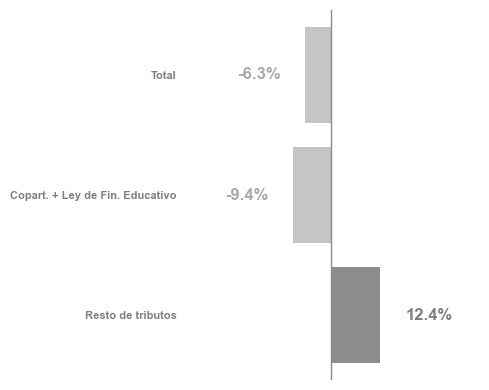

In [ ]:
# Categorías correctas (coinciden con las columnas)

categorias = ['Resto de tributos','Copart. + Ley de Fin. Educativo','Total']

df_vi = df_filtrado[lista_8].pct_change(12) * 100

df_vi = df_vi.fillna(-100)

# Convertir variación en vector
variacion = df_vi.tail(1).values.flatten()

# Crear figura
fig, ax = plt.subplots(figsize=(5, 4))

# Posiciones
y = np.arange(len(categorias))

# Crear colores según signo
colores = ["#8C8C8C" if v > 0 else "#C5C5C5" for v in variacion]

# Barras
ax.barh(
    y,
    variacion,
    color=colores
)

# Línea vertical en cero
ax.axvline(0, color='#8C8C8C', linewidth=1)

# hacer barras más cortas
max_val = max(abs(variacion))
ax.set_xlim(-max_val*3, max_val*3)

# Etiquetas a la izquierda
ax.set_yticks(y)
ax.tick_params(axis='y', length=0)
ax.set_yticklabels(categorias, fontname="Arial", fontsize=8, color="#7F7F7F", fontweight='bold')


# Ocultar bordes
for spine in ax.spines.values():
    spine.set_visible(False)

# Grid vertical
ax.xaxis.grid(False)

# Ocultar el eje x
ax.get_xaxis().set_visible(False)

# Texto de valores

offset = max_val * 0.5

for i, v in enumerate(variacion):

    if v > 0:
        color = "#7F7F7F"
    else:
        color = "#AAA9A9"

    ax.text(
        v + (offset if v >= 0 else -offset),
        i,
        f"{v:.1f}%",
        ha='left' if v >= 0 else 'right',
        va='center',
        fontname='Arial',
        fontsize=12,
        color=color,
        fontweight="bold"
    )

# Quitar etiquetas de ejes
ax.set_xlabel("")
ax.set_ylabel("")

plt.savefig(os.path.join(ruta_completa, '12. Copa_Resto_Total_barras_hor_AcumAA.png'),
            dpi=300,
            bbox_inches='tight')

plt.tight_layout()
plt.show()

--------------------------------------------------

---------------------------------------------------------

#  --------Transferencias Nacion a PBA--------

#### Fondos que más transferencias recibieron

In [ ]:
# Cantidad de transferencias para analizar los mayores montos

cantidad = 6

top_x = (
    df_filtrado_tr
    .filter(regex='_defl$')
    .drop(columns=['Total_transf_defl', 'Resto_trans_defl'], errors='ignore')
    .loc[
        (fiscal_db_tr.index.year == ANIO) &
        (fiscal_db_tr.index.month == MES)
    ]
    .iloc[0]
    .nlargest(cantidad)
)


top_x

Plan Nacional de Alfabetizacion_defl                         18438.11
Gestion Educativa y Politicas Socioeducativas_defl           17258.68
Fortalecimiento de los Sistemas Provinciales de Salud_defl    3177.42
Regulacion de la Ablacion e Implantes_defl                     666.60
Servicio Estadistico_defl                                       27.46
Acciones de Formacion Docente_defl                               0.00
Name: 2026-04-01 00:00:00, dtype: float64

In [ ]:
# Las transferencias que más acumularon el los últimos 13 meses

top_x_13m = (
    df_filtrado_tr
    .filter(regex='_defl$')
    .drop(columns=['Total_transf_defl', 'Resto_trans_defl'], errors='ignore')
    .tail(13)
    .sum()
    .nlargest(cantidad)
)

top_x_13m

Funcionamiento de Hospitales_defl                            246843.98
Plan Nacional de Alfabetizacion_defl                         163933.87
Gestion Educativa y Politicas Socioeducativas_defl           118498.10
Fortalecimiento de los Sistemas Provinciales de Salud_defl    16794.97
Regulacion de la Ablacion e Implantes_defl                     6994.30
Informacion y Evaluacion de la Calidad Educativa_defl          2172.69
dtype: float64

In [ ]:
lista_top_x_acum = [
                            'Funcionamiento de Hospitales_defl_acum',
                            'Plan Nacional de Alfabetizacion_defl_acum',
                            #'Servicio Estadistico_defl_acum',
                           # 'Fortalecimiento de los Sistemas Provinciales de Salud_defl_acum',
                           # 'Relaciones con las Provincias y Desarrollo Regional_defl_acum',
                            'Gestion Educativa y Politicas Socioeducativas_defl',
                            #'Regulacion de la Ablacion e Implantes_defl_acum'
                    ]

df_filtrado_tr['resto_top_x_acum'] = (
    df_filtrado_tr['Total_transf_defl_acum'] -
    df_filtrado_tr[lista_top_x_acum].sum(axis=1))

etiquetas_top_x_acum = [
                            'Resto Transferencias',
                           # 'Regulacion de la Ablacion \n e Implantes',
                            #'Relaciones con las Provincias y \n Desarrollo Regional',
                            #'Fortalecimiento de los Sistemas  \nProvinciales de Salud',
                            #'Servicio Estadistico',
                            'Funcionamiento de Hospitales',
                            'Gestion Educativa y \nPoliticas Socioeducativas',
                            'Plan Nacional de Alfabetizacion',
                            'Total'
]

#### Gráfico de barras Transferencias Totales:
* Total RON
* Copart. + Ley de Fin. Educativo
* Resto de tributos


-----  *lista_8*  ------

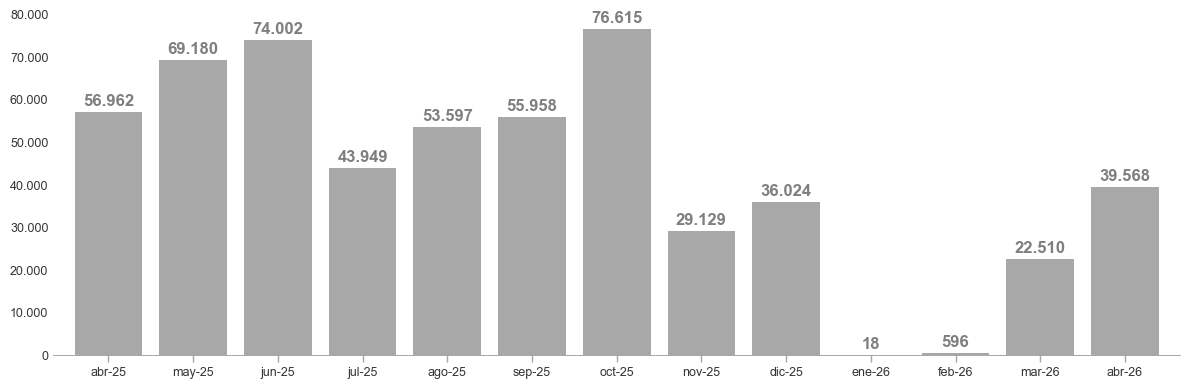

In [ ]:
# Creación del DataFrame

# ---------------------------
# Preparación de datos
# ---------------------------

barras = ['Total_transf_defl']

# Tomar últimos 13 meses
ultimo_13_meses = df_filtrado_tr.tail(13)

# Incluir fecha + variable
df_grafico_tot = ultimo_13_meses[['Total_transf_defl']].copy()

# ---------------------------
# Gráfico
# ---------------------------

fig, ax = plt.subplots(figsize=(12, 4))

# Resetear índice
df_grafico_tot = df_grafico_tot.reset_index(drop=True)

df_grafico_tot.plot(
    kind='bar',
    ax=ax,
    color=["#A8A8A8"],
    width=0.8
)

# Etiquetas arriba de cada barra
offset = df_grafico_tot[barras[0]].max() * 0.01

for i, v in enumerate(df_grafico_tot[barras[0]]):
    ax.text(
        i,
        v + offset,
        f"{v:,.0f}".replace(",", "."),  # 🔑 cambio acá
        ha='center',
        va='bottom',
        fontsize=12,
        fontname='Arial',
        fontweight='bold',
        color='#7F7F7F'
    )

# Eje Y con puntos en miles
ax.yaxis.set_major_formatter(
    mtick.FuncFormatter(lambda x, p: f"{x:,.0f}".replace(",", "."))
)

# ---------------------------
# Formato de fechas (español)
# ---------------------------

meses_esp = ['ene', 'feb', 'mar', 'abr', 'may', 'jun',
             'jul', 'ago', 'sep', 'oct', 'nov', 'dic']

fechas_esp = [
    f"{meses_esp[d.month-1]}-{str(d.year)[-2:]}"
    for d in pd.to_datetime(ultimo_13_meses.index)
]


positions = np.arange(len(df_grafico.index))
ax.set_xticks
ax.set_xticklabels(fechas_esp, rotation=0)

# ---------------------------
# Estética
# ---------------------------

ax.set_xlabel('')

# Spines
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_visible(False)
ax.spines['bottom'].set_linewidth(0.5)
ax.spines['bottom'].set_color("#838383")

# Ticks
ax.tick_params(axis='x', length=5, width=1, color='#A8A8A8')
ax.tick_params(axis='y', length=0, color='#A8A8A8')

# Fuente general

for label in (ax.get_xticklabels() + ax.get_yticklabels()):
    label.set_fontname('Arial')
    #label.set_fontweight('bold')
    label.set_fontsize(9)
    label.set_color("#353535")


for tick in ax.yaxis.get_major_ticks():
    tick.label1.set_fontname('Arial')
    tick.label1.set_fontsize(9)
    #tick.label1.set_fontweight('bold')
    tick.label1.set_color("#353535")

# Quitar leyenda
ax.legend().remove()

# ---------------------------
# Export / render
# ---------------------------

plt.tight_layout()

plt.rcParams['pdf.fonttype'] = 42
plt.rcParams['ps.fonttype'] = 42
plt.rcParams['svg.fonttype'] = 'none'

#ax.yaxis.grid(True, linestyle='-', linewidth=0.9, alpha=0.3)

# plt.savefig("grafico_final.pdf", bbox_inches="tight")
# plt.savefig("grafico_final.svg", bbox_inches="tight")

plt.savefig(os.path.join(ruta_completa, '13. Transf_Total_barras.png'),
            dpi=300,
            bbox_inches='tight')

plt.show()

#### Gráfico de barras apiladas acumulado:
* Funcionamiento Hospital de Cuenca Alta Nestor Kirchner
* Gestion Educativa y Politicas Socioeducativas
* Regulacion de la Ablacion e Implantes
* Plan Nacional de Alfabetizacion
* Fortalecimiento de los Sistemas Provinciales de Salud
* Resto trans


-----  *lista_9*  ------

In [ ]:
# Tomar último y mismo mes año anterior

df_temp = df_filtrado_tr.copy()

df_temp['anio'] = df_temp.index.year
df_temp['mes'] = df_temp.index.month

df_grafico_9 = df_temp[
    ((df_temp['anio'] == ANIO) & (df_temp['mes'] == MES)) |
    ((df_temp['anio'] == ANIO - 1) & (df_temp['mes'] == MES))
][lista_9]

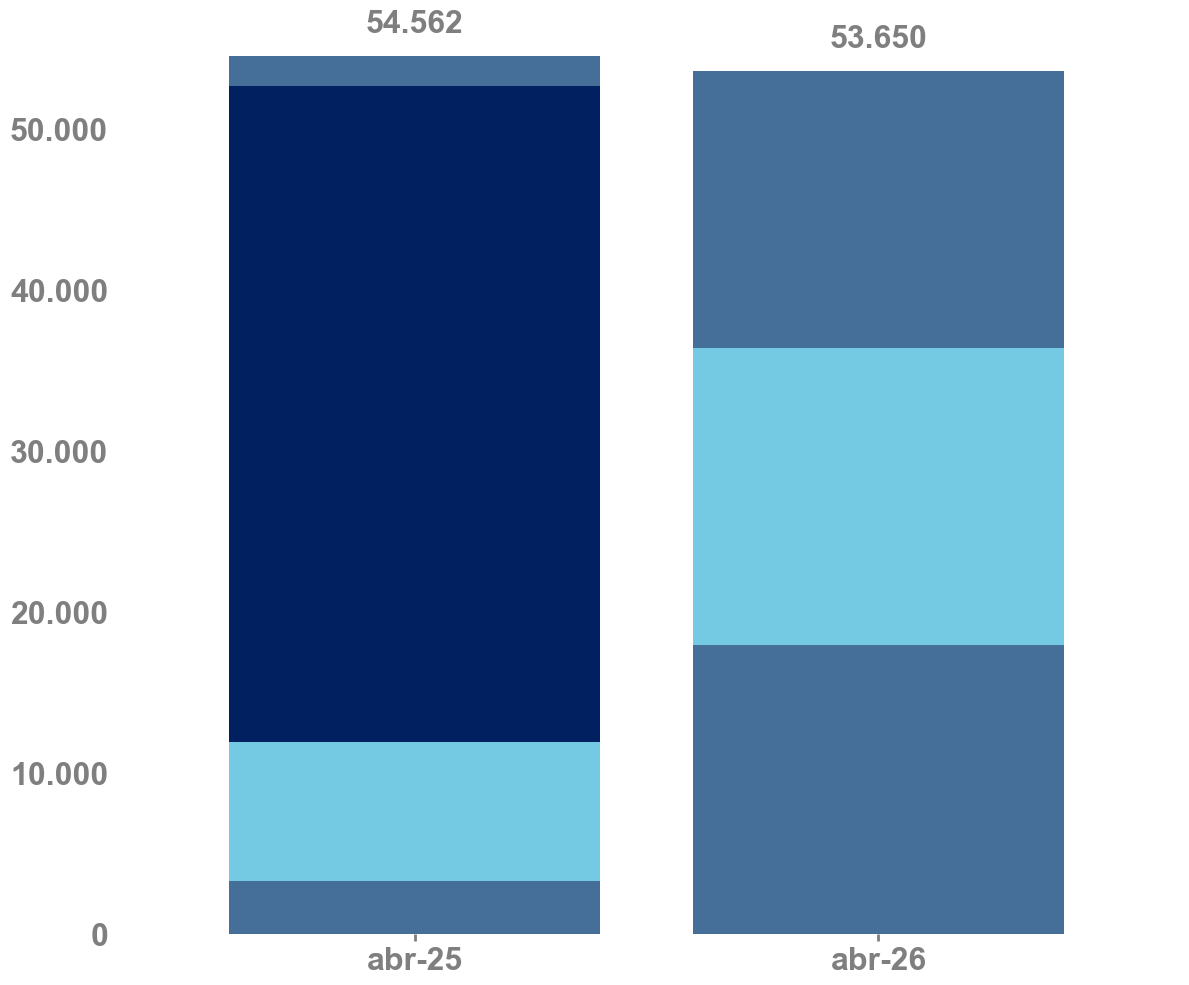

In [ ]:
# -----------------------------
# FIGURA
# -----------------------------
#colores = ['#A8A8A8'] + ['#00B7C5','#3F749A','#6BAED6','#9ECAE1','#C6DBEF']

colores_tr = ['#456F99','#74C9E3','#002060']

fig, ax = plt.subplots(figsize=(12,10))


# -----------------------------
# BARRAS APILADAS
# -----------------------------
df_grafico_9.plot(
    kind='bar',
    stacked=True,
    ax=ax,
    color=colores_tr,
    width=0.8
)

# -----------------------------
# ETIQUETAS DE TOTAL
# -----------------------------
totales = df_grafico_9.sum(axis=1)

for i, total in enumerate(totales):

    ax.text(
        i,
        total + (totales.max() * 0.02),  # offset dinámico
        f'{total:,.0f}'.replace(',', '.'),
        ha='center',
        va='bottom',
        fontsize=23,
        fontname='Arial',
        fontweight='bold',
        color='#7F7F7F'
    )

# -----------------------------
# EJE X (fechas en español)
# -----------------------------
meses_esp = ['ene', 'feb', 'mar', 'abr', 'may', 'jun',
             'jul', 'ago', 'sep', 'oct', 'nov', 'dic']

fechas_esp = [
    f"{meses_esp[d.month-1]}-{str(d.year)[-2:]}"
    for d in df_grafico_9.index
]

ax.set_xticklabels(fechas_esp, rotation=0)
ax.set_xlabel('')

# -----------------------------
# ESTILO
# -----------------------------
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_visible(False)
ax.spines['bottom'].set_visible(False)

ax.tick_params(axis='x', length=5, width=2, color='#7F7F7F')
ax.tick_params(axis='y', length=0)

for label in (ax.get_xticklabels() + ax.get_yticklabels()):
    label.set_fontname('Arial')
    label.set_fontweight('bold')
    label.set_fontsize(23)
    label.set_color('#7F7F7F')

# -----------------------------
# FORMATO EJE Y
# -----------------------------
ax.yaxis.set_major_formatter(
    ticker.FuncFormatter(lambda x, pos: f'{x:,.0f}'.replace(',', '.'))
)

for tick in ax.yaxis.get_major_ticks():
    tick.label1.set_fontname('Arial')
    tick.label1.set_fontsize(23)
    tick.label1.set_fontweight('bold')
    tick.label1.set_color('#7F7F7F')

# -----------------------------
# LIMPIEZA
# -----------------------------
plt.legend().remove()
plt.tight_layout()

plt.rcParams['pdf.fonttype'] = 42
plt.rcParams['ps.fonttype'] = 42
plt.rcParams['svg.fonttype'] = 'none'

plt.savefig(os.path.join(ruta_completa, '14. Desagregado_muni_barras_apiladas.png'),
            dpi=300,
            bbox_inches='tight')

plt.show()

#### Gráfico de barras horizontales con eje centrado YoY:
* Funcionamiento Hospital de Cuenca Alta Nestor Kirchner
* Gestion Educativa y Politicas Socioeducativas
* Regulacion de la Ablacion e Implantes
* Plan Nacional de Alfabetizacion
* Fortalecimiento de los Sistemas Provinciales de Salud
* Resto trans


-----  *lista_9*  ------

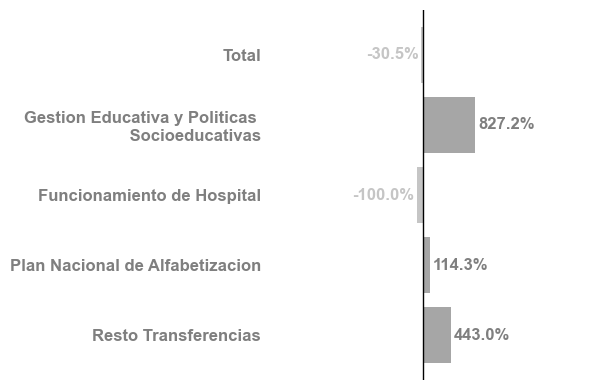

In [ ]:
lista_9_1 = lista_9 + ['Total_transf_defl']

# Variación interanual
df_vi = df_filtrado_tr[lista_9_1].pct_change(12) * 100

# 🔑 Reemplazos clave
df_vi = df_vi.replace([np.inf, -np.inf], np.nan)  # sacar infinitos
df_vi = df_vi.fillna(-100)  # NaN → -100%

# Vector final
variacion = df_vi.tail(1).iloc[0]

# Crear figura
fig, ax = plt.subplots(figsize=(6, 4))

y = np.arange(len(etiquetas_9))

# Colores
colores = ["#A6A6A6" if v > 0 else "#C5C5C5" for v in variacion]

# Barras
ax.barh(y, variacion, color=colores)

# Línea en cero
ax.axvline(0, color='black', linewidth=1)

# 🔑 Rango robusto (clave para evitar el error)
max_val = np.nanmax(np.abs(variacion))
if not np.isfinite(max_val) or max_val == 0:
    max_val = 1

ax.set_xlim(-max_val * 3, max_val * 3)

# Etiquetas
ax.set_yticks(y)
ax.tick_params(axis='y', length=0)
ax.set_yticklabels(
    etiquetas_9,
    fontname="Arial",
    fontsize=12,
    color="#7F7F7F",
    fontweight='bold'
)

# Estética
for spine in ax.spines.values():
    spine.set_visible(False)

ax.xaxis.grid(False)
ax.get_xaxis().set_visible(False)

# Texto
offset = max_val * 0.05  # mejor proporcional chico

for i, v in enumerate(variacion):

    color = "#7F7F7F" if v > 0 else "#C5C5C5"

    ax.text(
        v + (offset if v >= 0 else -offset),
        i,
        f"{v:.1f}%",
        ha='left' if v >= 0 else 'right',
        va='center',
        fontname='Arial',
        fontsize=12,
        color=color,
        fontweight="bold"
    )

ax.set_xlabel("")
ax.set_ylabel("")

plt.savefig(os.path.join(ruta_completa, '15. Desagregado_muni_barras_hor_AA.png'),
            dpi=300,
            bbox_inches='tight')

plt.tight_layout()
plt.show()

#### Gráfico de barras apiladas último año y año anterior:

* Funcionamiento de Hospitales
* Regulacion de la Ablacion e Implantes
* Plan Nacional de Alfabetizacion
* Resto trans


-----  *lista_9*  ------

#### Gráfico de barras apiladas acumulado último año y año anterior:

* Funcionamiento Hospital de Cuenca Alta Nestor Kirchner
* Gestion Educativa y Politicas Socioeducativas
* Regulacion de la Ablacion e Implantes
* Plan Nacional de Alfabetizacion
* Fortalecimiento de los Sistemas Provinciales de Salud
* Resto trans


-----  *lista_10*  ------

In [ ]:
df_grafico_10 = df_filtrado_tr[
    ((df_temp['anio'] == ANIO) & (df_temp['mes'] == MES)) |
    ((df_temp['anio'] == ANIO - 1) & (df_temp['mes'] == MES))
    ][lista_10]


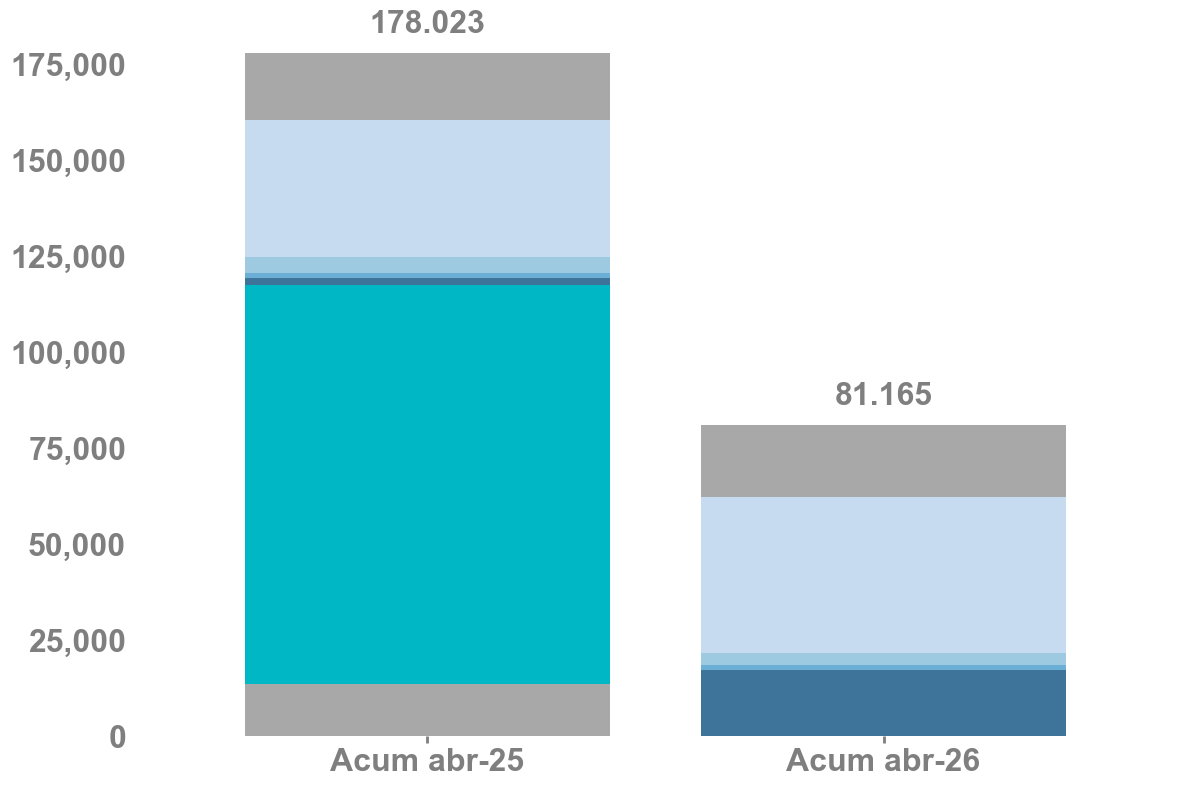

In [ ]:
# -----------------------------
# FIGURA
# -----------------------------
colores_tr = ['#A8A8A8'] + ['#00B7C5','#3F749A','#6BAED6','#9ECAE1','#C6DBEF']

fig, ax = plt.subplots(figsize=(12,8))

# -----------------------------
# BARRAS APILADAS
# -----------------------------
df_grafico_10.plot(
    kind='bar',
    stacked=True,
    ax=ax,
    color=colores_tr,
    width=0.8
)

# -----------------------------
# ETIQUETAS DE TOTAL
# -----------------------------
totales = df_grafico_10.sum(axis=1)

for i, total in enumerate(totales):

    ax.text(
        i,
        total + (totales.max() * 0.02),
        f'{total:,.0f}'.replace(',', '.'),
        ha='center',
        va='bottom',
        fontsize=23,
        fontname='Arial',
        fontweight='bold',
        color='#7F7F7F'
    )

# -----------------------------
# EJE X (fechas en español)
# -----------------------------
meses_esp = ['ene', 'feb', 'mar', 'abr', 'may', 'jun',
             'jul', 'ago', 'sep', 'oct', 'nov', 'dic']

fechas_esp = [
    f"Acum {meses_esp[d.month-1]}-{str(d.year)[-2:]}"
    for d in df_grafico_10.index
]

ax.set_xticks(range(len(fechas_esp)))
ax.set_xticklabels(fechas_esp, rotation=0)

ax.set_xlabel('')

# -----------------------------
# ESTILO (igual al otro gráfico)
# -----------------------------
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_visible(False)
ax.spines['bottom'].set_visible(False)

ax.tick_params(axis='x', length=5, width=2, color='#7F7F7F')
ax.tick_params(axis='y', length=0)

for label in (ax.get_xticklabels() + ax.get_yticklabels()):
    label.set_fontname('Arial')
    label.set_fontweight('bold')
    label.set_fontsize(23)
    label.set_color('#7F7F7F')

# -----------------------------
# FORMATO EJE Y
# -----------------------------
ax.yaxis.set_major_formatter(mtick.StrMethodFormatter('{x:,.0f}'))

for tick in ax.yaxis.get_major_ticks():
    tick.label1.set_fontname('Arial')
    tick.label1.set_fontsize(23)
    tick.label1.set_fontweight('bold')
    tick.label1.set_color('#7F7F7F')

# -----------------------------
# LIMPIEZA
# -----------------------------
plt.legend().remove()
plt.tight_layout()

plt.rcParams['pdf.fonttype'] = 42
plt.rcParams['ps.fonttype'] = 42
plt.rcParams['svg.fonttype'] = 'none'

plt.savefig(os.path.join(ruta_completa, '16. Desagregado_muni_barras_apil_AcumAA.png'),
            dpi=300,
            bbox_inches='tight')

#plt.savefig("barras_RP_RON.svg", bbox_inches="tight")
plt.show()

#### Gráfico de barras horizontales con eje centrado Acumualado YoY:
* Funcionamiento Hospital de Cuenca Alta Nestor Kirchner
* Gestion Educativa y Politicas Socioeducativas
* Regulacion de la Ablacion e Implantes
* Plan Nacional de Alfabetizacion
* Fortalecimiento de los Sistemas Provinciales de Salud
* Resto trans


-----  *lista_10*  ------

----- *etiquetas_10* -----

In [ ]:
etiquetas_top_x_acum

['Resto Transferencias',
 'Funcionamiento de Hospitales',
 'Gestion Educativa y \nPoliticas Socioeducativas',
 'Plan Nacional de Alfabetizacion',
 'Total']

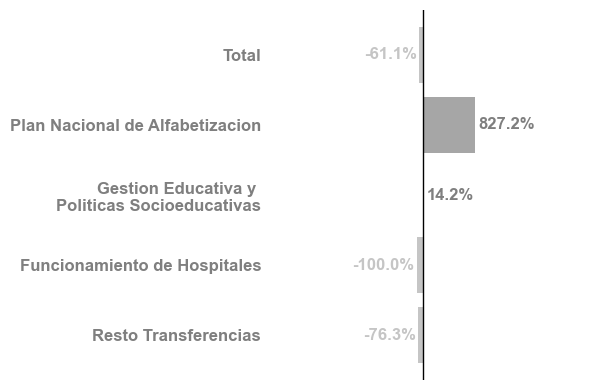

In [ ]:

lista_10_1 = ['resto_top_x_acum'] + lista_top_x_acum + ['Total_transf_defl_acum']

# Variación interanual
df_vi = df_filtrado_tr[lista_10_1].pct_change(12) * 100

# Reemplazos
df_vi = df_vi.replace([np.inf, -np.inf], np.nan)
df_vi = df_vi.fillna(-100)

# Vector final
variacion = df_vi.tail(1).values.flatten()

# Crear figura
fig, ax = plt.subplots(figsize=(6, 4))

y = np.arange(len(etiquetas_top_x_acum))

# Colores
colores = ["#A6A6A6" if v > 0 else "#C5C5C5" for v in variacion]

# Barras
ax.barh(y, variacion, color=colores)

# Línea en cero
ax.axvline(0, color='black', linewidth=1)

# Rango robusto
max_val = np.nanmax(np.abs(variacion))
if not np.isfinite(max_val) or max_val == 0:
    max_val = 1

ax.set_xlim(-max_val * 3, max_val * 3)

# Etiquetas
ax.set_yticks(y)
ax.tick_params(axis='y', length=0)
ax.set_yticklabels(
    etiquetas_top_x_acum,
    fontname="Arial",
    fontsize=12,
    color="#7F7F7F",
    fontweight='bold'
)

# Estética
for spine in ax.spines.values():
    spine.set_visible(False)

ax.xaxis.grid(False)
ax.get_xaxis().set_visible(False)

# Texto
offset = max_val * 0.05

for i, v in enumerate(variacion):

    color = "#7F7F7F" if v > 0 else "#C5C5C5"

    ax.text(
        v + (offset if v >= 0 else -offset),
        i,
        f"{v:.1f}%",
        ha='left' if v >= 0 else 'right',
        va='center',
        fontname='Arial',
        fontsize=12,
        color=color,
        fontweight="bold"
    )

ax.set_xlabel("")
ax.set_ylabel("")

plt.savefig(os.path.join(ruta_completa, '17. Desagregado_muni_barras_hor_AcumAA.png'),
            dpi=300,
            bbox_inches='tight')

plt.tight_layout()
plt.show()